# ML Pipeline: Predicting Citation Impact

**Objective**: Build a modular ML pipeline to predict citation impact for publications using multiple models and interpretability methods.

**Target Variable**: `citations_first_2y_exact` (regression task, exact citations from publication day to +730 days via OpenAlex API).

**Additional exact targets**:
- `citations_year_1_exact`: citations from publication day to day 365.
- `citations_year_2_exact`: citations from day 366 to day 730.
- `normalized_2y_cites_exact`: compatibility alias of `citations_first_2y_exact`.

**Dataset**: `New_work/data/openalex_output/works.csv` (processed from raw OpenAlex export + exact citation enrichment).

**Approach**:
1. **Baseline**: Linear & Negative Binomial Regression
2. **Main Models**: XGBoost, LightGBM, CatBoost (with 3 train-test strategies: random, time-based, stratified)
3. **Interpretability**: SHAP values on top of gradient boosted models
4. **Validation**: Random Forest as parallel model for feature importance cross-check

**Pipeline Structure**: Clear separation of concerns-load -> prepare -> exact target enrichment -> baseline -> main models -> interpret -> validate -> summarize

In [ ]:
## Section 1: Setup & Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Gradient boosted models
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Interpretability
import shap

# Statsmodels for Negative Binomial Regression
import statsmodels.api as sm
from statsmodels.genmod.families import NegativeBinomial

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful")

✓ All imports successful


## Section 2: Data Loading & Inspection

In [98]:
# Load and process OpenAlex works data
import ast

data_path = Path(r"C:\Users\locos\Documents\CiampittiLab\Publication_analysis\New_work\data\openalex_output\works.csv")
df_raw = pd.read_csv(data_path, low_memory=False)

def _safe_parse_list(value):
    """Parse stringified Python/JSON list safely."""
    if pd.isna(value) or value == "":
        return []
    if isinstance(value, list):
        return value
    try:
        return ast.literal_eval(value)
    except Exception:
        return []

def _citations_in_window(counts_str, pub_year, n_years):
    """Approximate yearly citation sum from counts_by_year (calendar-year based)."""
    if pd.isna(pub_year):
        return np.nan
    counts = _safe_parse_list(counts_str)
    if not isinstance(counts, list):
        return 0.0

    start_year = int(pub_year)
    end_year = start_year + n_years - 1
    total = 0.0
    for row in counts:
        if not isinstance(row, dict):
            continue
        year = row.get("year")
        cites = row.get("cited_by_count", 0)
        try:
            year = int(year)
            cites = float(cites)
        except Exception:
            continue
        if start_year <= year <= end_year:
            total += cites
    return total

def _keyword_stats(keywords_str):
    kws = _safe_parse_list(keywords_str)
    if not kws:
        return pd.Series([0, 0.0, 0.0], index=["n_keywords", "keywords_score_mean", "keywords_score_max"] )

    scores = []
    for k in kws:
        if isinstance(k, dict):
            try:
                scores.append(float(k.get("score", 0.0)))
            except Exception:
                continue

    if len(scores) == 0:
        return pd.Series([len(kws), 0.0, 0.0], index=["n_keywords", "keywords_score_mean", "keywords_score_max"] )
    return pd.Series([len(kws), float(np.mean(scores)), float(np.max(scores))], index=["n_keywords", "keywords_score_mean", "keywords_score_max"] )

# Build modeling dataframe from OpenAlex schema
df = pd.DataFrame({
    "article_id": df_raw["openalex_id"],
    "publication_year": pd.to_numeric(df_raw["publication_year"], errors="coerce"),
    "publication_date": df_raw["publication_date"],
    "journal_display_name": df_raw["source_display_name"],
    "author_type": df_raw["queried_author_position"].fillna("unknown"),
    "topic_subfield": df_raw["primary_subfield_name"],
    "topic_field": df_raw["primary_field_name"],
    "topic_domain": df_raw["primary_domain_name"],
    "type": df_raw["type"],
    "language": df_raw["language"],
    "source_type": df_raw["source_type"],
    "oa_status": df_raw["oa_status"],
    "primary_topic_score": pd.to_numeric(df_raw["primary_topic_score"], errors="coerce"),
    "authors_count": pd.to_numeric(df_raw["authors_count"], errors="coerce"),
    "countries_distinct_count": pd.to_numeric(df_raw["countries_distinct_count"], errors="coerce"),
    "institutions_distinct_count": pd.to_numeric(df_raw["institutions_distinct_count"], errors="coerce"),
    "locations_count": pd.to_numeric(df_raw["locations_count"], errors="coerce"),
    "referenced_works_count": pd.to_numeric(df_raw["referenced_works_count"], errors="coerce"),
    "apc_list_value_usd": pd.to_numeric(df_raw["apc_list_value_usd"], errors="coerce"),
    "apc_paid_value_usd": pd.to_numeric(df_raw["apc_paid_value_usd"], errors="coerce"),
    "citation_norm_percentile": pd.to_numeric(df_raw["citation_percentile_value"], errors="coerce"),
    "total_citations": pd.to_numeric(df_raw["cited_by_count"], errors="coerce"),
    "is_oa": df_raw["is_oa"],
    "any_repository_has_fulltext": df_raw["any_repository_has_fulltext"],
    "primary_location_is_oa": df_raw["primary_location_is_oa"],
    "source_is_oa": df_raw["source_is_oa"],
    "source_is_in_doaj": df_raw["source_is_in_doaj"],
    "source_is_core": df_raw["source_is_core"],
    "has_fulltext": df_raw["has_fulltext"],
    "queried_author_is_corresponding": df_raw["queried_author_is_corresponding"],
    "is_in_top_1_percent": df_raw["is_in_top_1_percent"],
    "is_in_top_10_percent": df_raw["is_in_top_10_percent"],
})

# Counts from nested list-like fields
keyword_stats = df_raw["keywords"].apply(_keyword_stats)
df = pd.concat([df, keyword_stats], axis=1)
df["sdgs"] = df_raw["sustainable_development_goals"].apply(lambda x: len(_safe_parse_list(x)))
df["funders_count"] = df_raw["funders"].apply(lambda x: len(_safe_parse_list(x)))
df["mesh_count"] = df_raw["mesh"].apply(lambda x: len(_safe_parse_list(x)))
df["title_word_count"] = df_raw["title"].fillna("").astype(str).str.split().str.len()
df["abstract_word_count"] = df_raw["abstract"].fillna("").astype(str).str.split().str.len()

# Approximate targets from counts_by_year (kept as reference only; exact target is built in next cell)
df["citations_first_2y"] = df_raw.apply(
    lambda r: _citations_in_window(r["counts_by_year"], r["publication_year"], n_years=2), axis=1
)
df["citations_first_3y"] = df_raw.apply(
    lambda r: _citations_in_window(r["counts_by_year"], r["publication_year"], n_years=3), axis=1
)
df["normalized_3y_cites_exact"] = df["citations_first_3y"] / 3.0
df["citations_per_year_3y"] = df["normalized_3y_cites_exact"]

# Convert bool-like columns to numeric 0/1
bool_cols = [
    "is_oa", "any_repository_has_fulltext", "primary_location_is_oa",
    "source_is_oa", "source_is_in_doaj", "source_is_core", "has_fulltext",
    "queried_author_is_corresponding", "is_in_top_1_percent", "is_in_top_10_percent",
]
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(int)

# Keep rows with valid year and publication_date
df = df.dropna(subset=["publication_year", "publication_date"]).copy()
df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce").astype(int)

print(f"Raw works shape: {df_raw.shape}")
print(f"Processed modeling shape (before exact enrichment): {df.shape}")
print("\nPreview of processed data:")
print(df.head(2))
print("\nMissing values (top 20):")
print(df.isnull().sum().sort_values(ascending=False).head(20))
print("\nNumeric summary (selected):")
print(df[["citations_first_2y", "total_citations", "authors_count", "publication_year"]].describe())

Raw works shape: (787, 75)
Processed modeling shape (before exact enrichment): (787, 44)

Preview of processed data:
    article_id  publication_year publication_date   journal_display_name  \
0  W2790329997              2018       2018-01-17  Global Change Biology   
1  W3095638759              2020       2020-10-27  Nature Communications   

  author_type topic_subfield                           topic_field  \
0       first   Soil Science  Agricultural and Biological Sciences   
1      middle   Soil Science  Agricultural and Biological Sciences   

    topic_domain    type language  ... keywords_score_max sdgs  funders_count  \
0  Life Sciences  review       en  ...           0.745361    1              0   
1  Life Sciences  review       en  ...           0.828767    1              0   

   mesh_count  title_word_count  abstract_word_count  citations_first_2y  \
0           0                14                  270                49.0   
1           0                 7                

In [99]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import time
import random

def get_exact_2y_cites(
    df,
    id_col="article_id",
    date_col="publication_date",
    email=None,
    sleep=0.12,
    checkpoint_path=None,
    save_every=100,
    timeout=20,
    max_retries=4,
):
    """
    Compute exact citation windows per paper using OpenAlex API.

    For each paper, create:
      - citations_year_1_exact: from publication day to +364 days
      - citations_year_2_exact: from +365 to +729 days
      - citations_first_2y_exact: year_1 + year_2
      - normalized_2y_cites_exact: compatibility alias (same as citations_first_2y_exact)

    Designed for large batches with resume/checkpoint support.
    """

    base_url = "https://api.openalex.org/works"
    session = requests.Session()
    user_agent = f"mailto:{email}" if email else "OpenAlex-Exact2Y-Citations"
    session.headers.update({"User-Agent": user_agent})

    def _normalize_work_id(work_id):
        s = str(work_id)
        if "/" in s:
            return s.rstrip("/").split("/")[-1]
        return s

    def _query_count(short_id, from_dt, to_dt):
        params = {
            "filter": f"cites:{short_id},from_publication_date:{from_dt},to_publication_date:{to_dt}",
            "select": "id",
            "per_page": 1,
        }
        if email:
            params["mailto"] = email

        for attempt in range(1, max_retries + 1):
            try:
                resp = session.get(base_url, params=params, timeout=timeout)
                status = resp.status_code
                if status in (429, 500, 502, 503, 504):
                    raise requests.HTTPError(f"HTTP {status}: retryable")
                resp.raise_for_status()
                count = resp.json().get("meta", {}).get("count", 0)
                return int(count) if count is not None else 0
            except Exception as e:
                if attempt == max_retries:
                    print(f"ERROR final ({short_id}): {e}")
                    return np.nan
                backoff = (2 ** (attempt - 1)) * sleep + random.uniform(0, sleep)
                time.sleep(backoff)
        return np.nan

    # Resume from checkpoint if available
    cached = {}
    cp = Path(checkpoint_path) if checkpoint_path else None
    if cp and cp.exists():
        cp_df = pd.read_csv(cp)
        required_cache_cols = {
            id_col,
            "citations_year_1_exact",
            "citations_year_2_exact",
            "citations_first_2y_exact",
        }
        if required_cache_cols.issubset(set(cp_df.columns)):
            for r in cp_df.itertuples(index=False):
                cached[getattr(r, id_col)] = (
                    getattr(r, "citations_year_1_exact"),
                    getattr(r, "citations_year_2_exact"),
                    getattr(r, "citations_first_2y_exact"),
                )
            print(f"Loaded checkpoint with {len(cached)} papers from {cp}")

    results = dict(cached)
    total = len(df)
    processed_now = 0

    for i, row in enumerate(df.itertuples(index=False), 1):
        work_id = getattr(row, id_col)
        pub_date_str = getattr(row, date_col)

        if work_id in results and not any(pd.isna(v) for v in results[work_id]):
            if i % 200 == 0 or i == total:
                print(f"  progress: {i}/{total} (cached/resumed)")
            continue

        short_id = _normalize_work_id(work_id)

        try:
            pub_date = datetime.strptime(str(pub_date_str), "%Y-%m-%d")
        except Exception:
            results[work_id] = (np.nan, np.nan, np.nan)
            continue

        y1_start = pub_date
        y1_end = pub_date + timedelta(days=364)
        y2_start = pub_date + timedelta(days=365)
        y2_end = pub_date + timedelta(days=729)

        y1_count = _query_count(short_id, y1_start.strftime("%Y-%m-%d"), y1_end.strftime("%Y-%m-%d"))
        y2_count = _query_count(short_id, y2_start.strftime("%Y-%m-%d"), y2_end.strftime("%Y-%m-%d"))

        if pd.isna(y1_count) or pd.isna(y2_count):
            total_2y = np.nan
        else:
            total_2y = int(y1_count) + int(y2_count)

        results[work_id] = (y1_count, y2_count, total_2y)
        processed_now += 1

        # Save incremental checkpoint for large runs
        if cp and (processed_now % save_every == 0):
            tmp = pd.DataFrame([
                {
                    id_col: k,
                    "citations_year_1_exact": v[0],
                    "citations_year_2_exact": v[1],
                    "citations_first_2y_exact": v[2],
                }
                for k, v in results.items()
            ])
            tmp.to_csv(cp, index=False)
            print(f"  checkpoint saved: {len(tmp)} rows")

        time.sleep(sleep)

        if i % 25 == 0 or i == total:
            print(f"  progress: {i}/{total}")

    out = df.copy()
    out["citations_year_1_exact"] = out[id_col].map(lambda k: results.get(k, (np.nan, np.nan, np.nan))[0])
    out["citations_year_2_exact"] = out[id_col].map(lambda k: results.get(k, (np.nan, np.nan, np.nan))[1])
    out["citations_first_2y_exact"] = out[id_col].map(lambda k: results.get(k, (np.nan, np.nan, np.nan))[2])
    out["normalized_2y_cites_exact"] = out["citations_first_2y_exact"]

    # Final checkpoint write
    if cp:
        final_cp = out[[id_col, "citations_year_1_exact", "citations_year_2_exact", "citations_first_2y_exact"]].copy()
        final_cp.to_csv(cp, index=False)
        print(f"Final checkpoint saved to {cp}")

    return out

# Apply exact 2-year enrichment (resume-safe for large collections)
checkpoint_file = Path(r"C:\Users\locos\Documents\CiampittiLab\Publication_analysis\New_work\data\openalex_output\works_exact_2y_checkpoint.csv")

required_exact_cols = {
    "citations_year_1_exact",
    "citations_year_2_exact",
    "citations_first_2y_exact",
    "normalized_2y_cites_exact",
}

if not required_exact_cols.issubset(set(df.columns)):
    df = get_exact_2y_cites(
        df,
        id_col="article_id",
        date_col="publication_date",
        email=None,
        sleep=0.12,
        checkpoint_path=checkpoint_file,
        save_every=100,
        timeout=20,
        max_retries=4,
    )
else:
    print("Exact 2-year citation columns already present; skipping API enrichment.")

# Persist processed dataset for reuse
processed_path = Path(r"C:\Users\locos\Documents\CiampittiLab\Publication_analysis\New_work\data\openalex_output\works_processed_for_ml.csv")
df.to_csv(processed_path, index=False)

print("\nExact citation enrichment summary:")
print(df[["citations_year_1_exact", "citations_year_2_exact", "citations_first_2y_exact"]].describe(include="all"))
print(f"Saved processed dataset to: {processed_path}")

Loaded checkpoint with 779 papers from C:\Users\locos\Documents\CiampittiLab\Publication_analysis\New_work\data\openalex_output\works_exact_2y_checkpoint.csv
  progress: 200/787 (cached/resumed)
  progress: 400/787 (cached/resumed)
  progress: 600/787 (cached/resumed)
  progress: 787/787 (cached/resumed)
Final checkpoint saved to C:\Users\locos\Documents\CiampittiLab\Publication_analysis\New_work\data\openalex_output\works_exact_2y_checkpoint.csv

Exact citation enrichment summary:
       citations_year_1_exact  citations_year_2_exact  \
count              787.000000              787.000000   
mean                11.012706               21.833545   
std                 29.748562               55.750685   
min                  0.000000                0.000000   
25%                  1.000000                2.000000   
50%                  4.000000                7.000000   
75%                  9.000000               19.000000   
max                578.000000             1056.000000   


In [100]:
# Sanity checks for exact engineered citation targets
required_cols = [
    "citations_year_1_exact",
    "citations_year_2_exact",
    "citations_first_2y_exact",
    "normalized_2y_cites_exact",
]

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise KeyError(f"Missing required engineered columns: {missing_required}")

print("Exact engineered target columns available:")
for col in required_cols:
    print(f"  - {col}")

print("\nSample exact target rows:")
sample_cols = [
    "article_id",
    "publication_date",
    "citations_year_1_exact",
    "citations_year_2_exact",
    "citations_first_2y_exact",
]
print(df[sample_cols].head(10))

print("\nRows with zero citations in first 2 real years:")
zero_2y = (df["citations_first_2y_exact"] == 0).sum()
print(f"{zero_2y} out of {len(df)}")

Exact engineered target columns available:
  - citations_year_1_exact
  - citations_year_2_exact
  - citations_first_2y_exact
  - normalized_2y_cites_exact

Sample exact target rows:
    article_id publication_date  citations_year_1_exact  \
0  W2790329997       2018-01-17                      18   
1  W3095638759       2020-10-27                      50   
2  W3002479026       2020-01-23                     122   
3  W2792040353       2018-02-27                      14   
4  W3035993398       2020-06-23                      67   
5  W3156629428       2021-04-19                      47   
6  W3021404478       2020-05-07                       3   
7  W2899925677       2018-11-01                       7   
8  W3208386427       2021-11-02                      18   
9  W3202470152       2021-09-29                      32   

   citations_year_2_exact  citations_first_2y_exact  
0                      37                        55  
1                     119                       169  
2    


TARGET VARIABLE: citations_first_2y_exact
Data type: int64
Null count: 0
Statistics:
count     787.000000
mean       32.846252
std        84.544088
min         0.000000
25%         4.000000
50%        12.000000
75%        27.000000
max      1634.000000
Name: citations_first_2y_exact, dtype: float64

Target distribution:


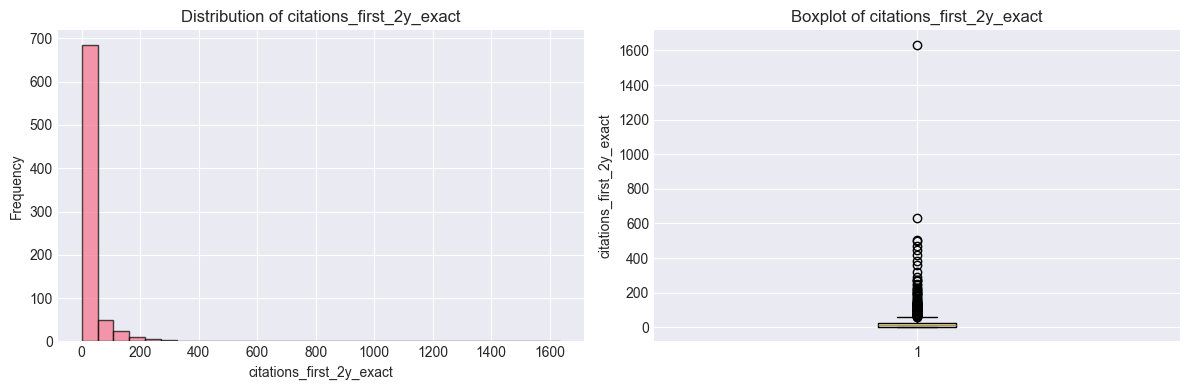

In [101]:
# Inspect target variable
TARGET = "citations_first_2y_exact"  # Exact total citations from day 0 to day 730

print(f"\n{'='*60}")
print(f"TARGET VARIABLE: {TARGET}")
print(f"{'='*60}")
print(f"Data type: {df[TARGET].dtype}")
print(f"Null count: {df[TARGET].isnull().sum()}")
print(f"Statistics:\n{df[TARGET].describe()}")
print(f"\nTarget distribution:")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[TARGET].dropna(), bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Distribution of {TARGET}")
axes[1].boxplot(df[TARGET].dropna(), vert=True)
axes[1].set_ylabel(TARGET)
axes[1].set_title(f"Boxplot of {TARGET}")
plt.tight_layout()
plt.show()

In [102]:
# Load and merge journal impact factor data
journal_if_path = Path("C:\\Users\\locos\\Documents\\CiampittiLab\\Publication_analysis\\data\\JOURNAL_IF_2025.csv")
journal_if = pd.read_csv(journal_if_path)

print(f"\n{'='*60}")
print(f"JOURNAL IMPACT FACTOR DATA")
print(f"{'='*60}")
print(f"Impact factor dataset shape: {journal_if.shape}")
print(f"Columns: {journal_if.columns.tolist()}")
print(f"\nSample impact factors:")
print(journal_if.head(10))

# Merge impact factor data with main dataset
df = df.merge(journal_if, left_on='journal_display_name', right_on='journal_name', how='left')

# Check for unmatched journals
unmatched = df[df['impact_factor'].isnull()]['journal_display_name'].unique()
print(f"\n{len(unmatched)} journals not found in impact factor database:")
print(unmatched[:10])  # Show first 10

# Fill missing impact factors with 0 (journals without available IF)
df['impact_factor'] = df['impact_factor'].fillna(0)

print(f"\nImpact Factor Statistics:")
print(df['impact_factor'].describe())
print(f"\nDataset shape after adding impact_factor: {df.shape}")
print(f"✓ Journal impact factor data merged successfully")


JOURNAL IMPACT FACTOR DATA
Impact factor dataset shape: (376, 2)
Columns: ['journal_name', 'impact_factor']

Sample impact factors:
                                        journal_name  impact_factor
0                                              Joule      23.776846
1                 Nature Reviews Earth & Environment      19.357401
2                     Annual Review of Plant Biology      19.109589
3                              Nature Sustainability      18.643116
4       UTS ePRESS (University of Technology Sydney)      17.666667
5                                            Science      17.321177
6  CGSPace A Repository of Agricultural Research ...      16.285714
7                              Nature Communications      14.686409
8           Renewable and Sustainable Energy Reviews      13.907861
9                                            Biochar      13.420420

127 journals not found in impact factor database:
<StringArray>
[                                                    '

## Section 3: Feature Preparation & Encoding

In [103]:
# Create a clean copy for feature preparation
df_model = df.copy()

# Target for regression (production default: p95-capped exact 2-year citations)
BASE_TARGET = "citations_first_2y_exact"
TARGET = f"{BASE_TARGET}_p95_capped"
LOWER_PERCENTILE = 0.00
UPPER_PERCENTILE = 0.95

if BASE_TARGET not in df_model.columns:
    raise KeyError(f"Base target column '{BASE_TARGET}' is missing from processed dataframe.")

base_target_numeric = pd.to_numeric(df_model[BASE_TARGET], errors="coerce")
if base_target_numeric.isna().all():
    raise ValueError(f"Base target '{BASE_TARGET}' is entirely NaN after numeric coercion.")

p95_upper = base_target_numeric.quantile(UPPER_PERCENTILE)
p95_lower = base_target_numeric.quantile(LOWER_PERCENTILE)
if base_target_numeric.min() <= 0:
    p95_lower = 0.0

df_model[TARGET] = base_target_numeric.clip(lower=p95_lower, upper=p95_upper)

print("=" * 70)
print("TARGET CONFIGURATION")
print("=" * 70)
print(f"Base target: {BASE_TARGET}")
print(f"Modeling target: {TARGET}")
print(f"Cap bounds: [{p95_lower:.2f}, {p95_upper:.2f}] (percentiles {LOWER_PERCENTILE:.0%}-{UPPER_PERCENTILE:.0%})")
print(f"Zero-citation rows kept: {(base_target_numeric == 0).sum()}")
print(f"Upper-tail values capped: {(base_target_numeric > p95_upper).sum()}")

# Drop columns that are IDs, leakage, or non-modeling artifacts when present
drop_candidates = [
    "article_id",
    "publication_date",
    "total_citations",
    "citation_norm_percentile",
    "citations_first_2y",
    "citations_first_3y",
    "citations_per_year_3y",
    "normalized_3y_cites_exact",
    "normalized_2y_cites_exact",
    "citations_year_1_exact",
    "citations_year_2_exact",
    "citations_first_2y_exact",
    "journal_name",
    "journal_publisher",
    "keywords_very_specific",
    "keywords_specific",
    "keywords_intermediate",
    "keywords_broad",
    "keywords_score_high",
    "keywords_score_medium",
    "keywords_score_low",
    "percentile_min",
    "percentile_max",
    'is_in_top_1_percent', 
    'is_in_top_10_percent',
    'primary_topic_score',
    'apc_list_value_usd', 
    'apc_paid_value_usd',
    'any_repository_has_fulltext', 
    'primary_location_is_oa',
    'source_is_in_doaj',
    'source_is_core', 
    'has_fulltext', 
    'queried_author_is_corresponding',
    'keywords_score_mean', 
    'keywords_score_max',
    'topic_domain',
    
]

drop_cols = [c for c in drop_candidates if c in df_model.columns]

# Separate target from features and remove rows with missing target
target_numeric = pd.to_numeric(df_model[TARGET], errors="coerce")
valid_target_mask = target_numeric.notna()
df_model = df_model.loc[valid_target_mask].copy()
y = target_numeric.loc[valid_target_mask].values

X_data = df_model.drop(columns=[TARGET] + drop_cols, errors="ignore")

# Remove constant columns (can break VIF and add noise)
constant_cols = [c for c in X_data.columns if X_data[c].nunique(dropna=False) <= 1]
if constant_cols:
    X_data = X_data.drop(columns=constant_cols, errors="ignore")
    print(f"Dropped {len(constant_cols)} constant columns: {constant_cols}")

print(f"Initial features shape: {X_data.shape}")
print(f"\nFeature columns ({len(X_data.columns)}):")
print(X_data.columns.tolist())

# Identify categorical and numerical columns
categorical_cols = X_data.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
numerical_cols = X_data.select_dtypes(include=["number"]).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")

TARGET CONFIGURATION
Base target: citations_first_2y_exact
Modeling target: citations_first_2y_exact_p95_capped
Cap bounds: [0.00, 137.70] (percentiles 0%-95%)
Zero-citation rows kept: 76
Upper-tail values capped: 40
Dropped 1 constant columns: ['mesh_count']
Initial features shape: (787, 22)

Feature columns (22):
['publication_year', 'journal_display_name', 'author_type', 'topic_subfield', 'topic_field', 'type', 'language', 'source_type', 'oa_status', 'authors_count', 'countries_distinct_count', 'institutions_distinct_count', 'locations_count', 'referenced_works_count', 'is_oa', 'source_is_oa', 'n_keywords', 'sdgs', 'funders_count', 'title_word_count', 'abstract_word_count', 'impact_factor']

Categorical columns (8): ['journal_display_name', 'author_type', 'topic_subfield', 'topic_field', 'type', 'language', 'source_type', 'oa_status']

Numerical columns (14): ['publication_year', 'authors_count', 'countries_distinct_count', 'institutions_distinct_count', 'locations_count', 'referenc

PREDICTOR-TARGET CORRELATION DIAGNOSTICS

Top 15 predictors by absolute Pearson correlation with target:
                    Feature  Pearson_r  Spearman_rho  Abs_Pearson_r
     referenced_works_count   0.403152      0.549617       0.403152
   countries_distinct_count   0.330429      0.340943       0.330429
institutions_distinct_count   0.295030      0.187433       0.295030
              authors_count   0.295030      0.187433       0.295030
              impact_factor   0.292984      0.309384       0.292984
            locations_count   0.289958      0.318432       0.289958
                       type   0.232277      0.028184       0.232277
                 n_keywords   0.170218      0.229311       0.170218
                topic_field   0.120270     -0.012020       0.120270
                source_type   0.120171      0.122226       0.120171
                       sdgs   0.115313      0.184099       0.115313
           title_word_count  -0.111734     -0.065477       0.111734
        abs

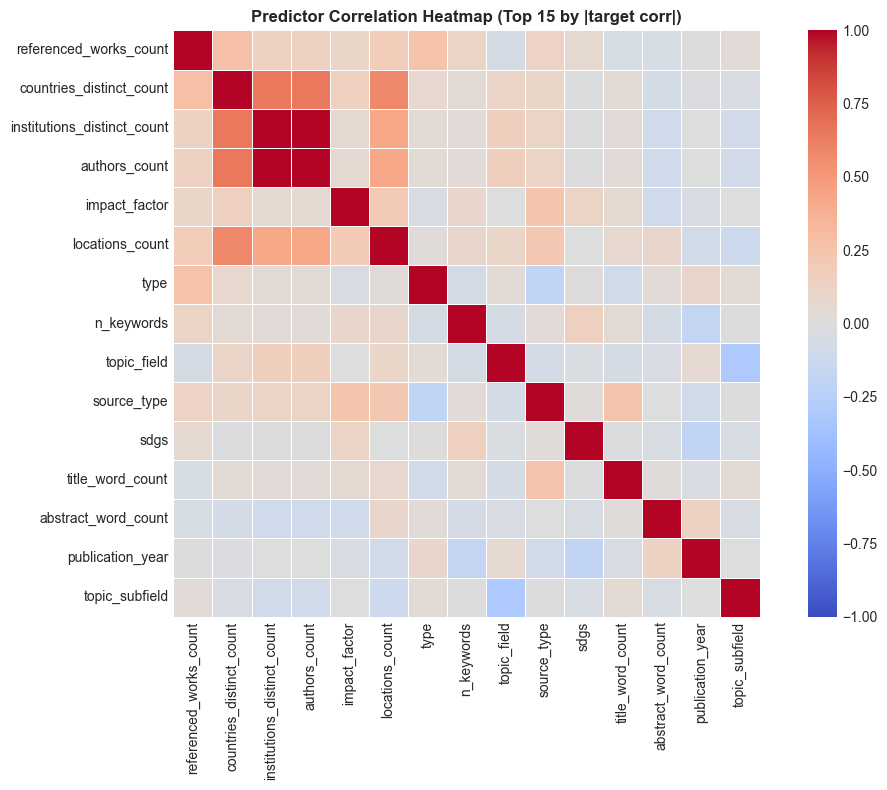


Top VIF values (multicollinearity check):
                    Feature        VIF
institutions_distinct_count        inf
              authors_count        inf
           publication_year 382.029871
                   language 323.283276
                source_type  16.547510
                 n_keywords  13.268080
           title_word_count  10.698600
                      is_oa   8.733300
                  oa_status   7.500631
             topic_subfield   5.818545
            locations_count   5.770420
   countries_distinct_count   5.057512
       journal_display_name   4.450450
                       sdgs   4.422678
                author_type   4.135844

Predictors with VIF > 10: 7
                    Feature        VIF
institutions_distinct_count        inf
              authors_count        inf
           publication_year 382.029871
                   language 323.283276
                source_type  16.547510
                 n_keywords  13.268080
           title_word_count  10

In [104]:
# Correlation diagnostics: predictor utility and co-dependence checks
print("=" * 80)
print("PREDICTOR-TARGET CORRELATION DIAGNOSTICS")
print("=" * 80)

# Build an analysis-only numeric matrix (do not modify X_data used later)
corr_X = X_data.copy()

# Numeric columns: coerce and impute median for stable correlations
for col in numerical_cols:
    corr_X[col] = pd.to_numeric(corr_X[col], errors="coerce")
    corr_X[col] = corr_X[col].fillna(corr_X[col].median())

# Categorical columns: encode to integer codes for correlation screening only
for col in categorical_cols:
    corr_X[col] = corr_X[col].astype(str).fillna("MISSING")
    corr_X[col], _ = pd.factorize(corr_X[col], sort=True)

# Ensure fully numeric matrix
corr_X = corr_X.apply(pd.to_numeric, errors="coerce").fillna(0)

# Target as numeric
y_corr = pd.to_numeric(df_model[TARGET], errors="coerce")
valid_rows = y_corr.notna()
corr_X_valid = corr_X.loc[valid_rows].copy()
y_corr_valid = y_corr.loc[valid_rows].copy()

# 1) Predictor vs target correlations (utility)
pearson_vals = corr_X_valid.corrwith(y_corr_valid, method="pearson")
spearman_vals = corr_X_valid.corrwith(y_corr_valid, method="spearman")

feature_target_corr = pd.DataFrame({
    "Feature": corr_X_valid.columns,
    "Pearson_r": pearson_vals.values,
    "Spearman_rho": spearman_vals.values,
})
feature_target_corr["Abs_Pearson_r"] = feature_target_corr["Pearson_r"].abs()
feature_target_corr = feature_target_corr.sort_values("Abs_Pearson_r", ascending=False)

print("\nTop 15 predictors by absolute Pearson correlation with target:")
print(feature_target_corr.head(15).to_string(index=False))

weak_predictors = feature_target_corr[feature_target_corr["Abs_Pearson_r"] < 0.05]
print(f"\nWeak linear-signal predictors (|r| < 0.05): {len(weak_predictors)}")
if len(weak_predictors) > 0:
    print(weak_predictors[["Feature", "Pearson_r"]].head(10).to_string(index=False))

# 2) Predictor co-dependence (pairwise feature correlation)
predictor_corr_abs = corr_X_valid.corr().abs()
upper = predictor_corr_abs.where(np.triu(np.ones(predictor_corr_abs.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Abs_r"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["Abs_r"] >= 0.80].sort_values("Abs_r", ascending=False)

print(f"\nHighly correlated predictor pairs (|r| >= 0.80): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print(high_corr_pairs.head(20).to_string(index=False))
else:
    print("No high-correlation predictor pairs found at this threshold.")

# 3) Heatmap of top utility predictors (helps visual inspection of co-dependence)
top_n_heatmap = 15
top_features = feature_target_corr.head(top_n_heatmap)["Feature"].tolist()
if len(top_features) > 1:
    plt.figure(figsize=(11, 8))
    sns.heatmap(
        corr_X_valid[top_features].corr(),
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
    )
    plt.title(f"Predictor Correlation Heatmap (Top {top_n_heatmap} by |target corr|)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

# 4) VIF (Variance Inflation Factor) for multicollinearity screening
#    Rule of thumb: VIF > 5 moderate concern, VIF > 10 strong concern
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_input = corr_X_valid.copy()
# Remove near-constant columns to avoid numerical issues
vif_input = vif_input.loc[:, vif_input.nunique(dropna=False) > 1]

vif_df = pd.DataFrame({
    "Feature": vif_input.columns,
    "VIF": [variance_inflation_factor(vif_input.values, i) for i in range(vif_input.shape[1])],
}).sort_values("VIF", ascending=False)

print("\nTop VIF values (multicollinearity check):")
print(vif_df.head(15).to_string(index=False))

vif_threshold = 10
high_vif = vif_df[vif_df["VIF"] > vif_threshold]
vif_drop_features = high_vif["Feature"].tolist()

print(f"\nPredictors with VIF > {vif_threshold}: {len(high_vif)}")
if len(high_vif) > 0:
    print(high_vif.to_string(index=False))
    print(f"\nFeatures marked for removal before modeling: {vif_drop_features}")
else:
    print("No features exceed the VIF threshold.")

print("\nInterpretation guide:")
print("- Strong predictor utility: larger |Pearson_r| and/or |Spearman_rho|.")
print("- Potential co-dependence risk: many high-correlation feature pairs and high VIF.")
print("- For coefficient interpretation (linear/GLM), reducing high VIF is usually recommended.")
print("- For pure prediction with tree models, correlated predictors are often less problematic.")

In [105]:
# Apply VIF-based feature reduction (from previous diagnostics cell)
print("Applying VIF-based feature reduction...")
if "vif_drop_features" in globals() and len(vif_drop_features) > 0:
    drop_in_X = [c for c in vif_drop_features if c in X_data.columns]
    X_data = X_data.drop(columns=drop_in_X, errors="ignore")
    categorical_cols = [c for c in categorical_cols if c in X_data.columns]
    numerical_cols = [c for c in numerical_cols if c in X_data.columns]
    print(f"Dropped {len(drop_in_X)} high-VIF features: {drop_in_X}")
else:
    print("No high-VIF features found (or diagnostics cell not run). Proceeding without drops.")

# Handle missing values
print("\nHandling missing values...")
X_data = X_data.fillna(X_data.mean(numeric_only=True))  # Numerical: fill with mean
for col in categorical_cols:
    if X_data[col].isnull().any():
        X_data[col] = X_data[col].fillna(X_data[col].mode()[0])  # Categorical: fill with mode

print(f"Missing values after imputation:\n{X_data.isnull().sum().sum()}")

# Encode categorical features using LabelEncoder
# (XGBoost, LightGBM, CatBoost can handle categorical natively, but we'll encode for Linear/Forest models)
label_encoders = {}
X_data_encoded = X_data.copy()

if categorical_cols:
    print(f"\nEncoding categorical features...")
    for col in categorical_cols:
        le = LabelEncoder()
        X_data_encoded[col] = le.fit_transform(X_data_encoded[col].astype(str))
        label_encoders[col] = le
        print(f"  {col}: {len(le.classes_)} unique values")

print(f"\nFinal feature matrix shape: {X_data_encoded.shape}")
print(f"Target shape: {y.shape}")

# Store for reference
X = X_data_encoded.values
feature_names = X_data_encoded.columns.tolist()
print(f"\nFeature names ready for modeling")

Applying VIF-based feature reduction...
Dropped 7 high-VIF features: ['institutions_distinct_count', 'authors_count', 'publication_year', 'language', 'source_type', 'n_keywords', 'title_word_count']

Handling missing values...
Missing values after imputation:
0

Encoding categorical features...
  journal_display_name: 237 unique values
  author_type: 3 unique values
  topic_subfield: 58 unique values
  topic_field: 16 unique values
  type: 10 unique values
  oa_status: 6 unique values

Final feature matrix shape: (787, 15)
Target shape: (787,)

Feature names ready for modeling


## Section 4: Train-Test Split Strategies

Three independent strategies to understand their trade-offs:
1. **Random 80/20**: Standard random split with stratification
2. **Time-Based**: Train on earlier years, test on recent years (temporal validation)
3. **Stratified**: Split stratified by primary_topic or key columns (group balance)

In [106]:
# Strategy 1: Random 80/20 Split
print("=" * 70)
print("STRATEGY 1: RANDOM 80/20 SPLIT")
print("=" * 70)
print("Pros: Standard, balanced sampling, reproducible")
print("Cons: May leak temporal patterns if publication year is important")
print("Use: General baseline comparison\n")

X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

print(f"Training set size: {X_train_s1.shape[0]}")
print(f"Test set size: {X_test_s1.shape[0]}")
print(f"Target distribution in train: mean={y_train_s1.mean():.2f}, std={y_train_s1.std():.2f}")
print(f"Target distribution in test: mean={y_test_s1.mean():.2f}, std={y_test_s1.std():.2f}")

STRATEGY 1: RANDOM 80/20 SPLIT
Pros: Standard, balanced sampling, reproducible
Cons: May leak temporal patterns if publication year is important
Use: General baseline comparison

Training set size: 629
Test set size: 158
Target distribution in train: mean=24.84, std=35.12
Target distribution in test: mean=27.10, std=37.81


In [107]:
# Strategy 2: Time-Based Split
print("\n" + "=" * 70)
print("STRATEGY 2: TIME-BASED SPLIT (Earlier years → train, Recent years → test)")
print("=" * 70)
print("Pros: Tests forward prediction; avoids data leakage; realistic scenario")
print("Cons: May imbalance class distributions; fewer recent samples")
print("Use: Validate model's ability to predict future citations\n")

# Get publication_year column (index in original data)
publication_year_col_idx = df_model.columns.get_loc('publication_year')
publication_year = df_model['publication_year'].values

# Split: older years (80%) for train, recent years (20%) for test
median_year = np.percentile(publication_year, 80)
train_mask_s2 = publication_year <= median_year
test_mask_s2 = publication_year > median_year

X_train_s2 = X[train_mask_s2]
X_test_s2 = X[test_mask_s2]
y_train_s2 = y[train_mask_s2]
y_test_s2 = y[test_mask_s2]

print(f"Split threshold year: {median_year:.0f}")
print(f"Training set size: {X_train_s2.shape[0]} (years ≤ {median_year:.0f})")
print(f"Test set size: {X_test_s2.shape[0]} (years > {median_year:.0f})")
print(f"Target distribution in train: mean={y_train_s2.mean():.2f}, std={y_train_s2.std():.2f}")
print(f"Target distribution in test: mean={y_test_s2.mean():.2f}, std={y_test_s2.std():.2f}")


STRATEGY 2: TIME-BASED SPLIT (Earlier years → train, Recent years → test)
Pros: Tests forward prediction; avoids data leakage; realistic scenario
Cons: May imbalance class distributions; fewer recent samples
Use: Validate model's ability to predict future citations

Split threshold year: 2023
Training set size: 687 (years ≤ 2023)
Test set size: 100 (years > 2023)
Target distribution in train: mean=27.62, std=37.14
Target distribution in test: mean=9.32, std=15.97


In [108]:
# Strategy 3: Stratified Split (by stable categorical group when available)
print("\n" + "=" * 70)
print("STRATEGY 3: STRATIFIED SPLIT (Group-balanced split)")
print("=" * 70)
print("Pros: Ensures balanced representation of key groups in train/test")
print("Cons: No temporal validation; may overfit to group patterns")
print("Use: Confirm feature importance generalizes across publication groups\n")

# Pick the best available stratification column
stratify_candidates = ["author_type", "source_type", "topic_field", "topic_subfield"]
stratify_col = next((c for c in stratify_candidates if c in df_model.columns), None)

if stratify_col is not None:
    stratify_vector = df_model[stratify_col].astype(str).fillna("unknown")
else:
    # Fallback: create bins from target if no suitable categorical column exists
    stratify_col = "target_bins"
    stratify_vector = pd.qcut(y, q=4, duplicates="drop").astype(str)

class_counts = pd.Series(stratify_vector).value_counts(dropna=False)
can_stratify = (len(class_counts) >= 2) and (class_counts.min() >= 2)

if can_stratify:
    X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=stratify_vector
    )
    split_note = f"Stratified by {stratify_col}"
else:
    # Last-resort fallback to random split if stratification is not feasible
    X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
    )
    split_note = "Fallback to random split (insufficient class counts for stratification)"

print(f"Split mode: {split_note}")
print(f"Training set size: {X_train_s3.shape[0]}")
print(f"Test set size: {X_test_s3.shape[0]}")
print(f"Target distribution in train: mean={y_train_s3.mean():.2f}, std={y_train_s3.std():.2f}")
print(f"Target distribution in test: mean={y_test_s3.mean():.2f}, std={y_test_s3.std():.2f}")

print(f"\nStratification diagnostic (full dataset):")
print(class_counts.to_string())
print("✓ All three train-test strategies ready")


STRATEGY 3: STRATIFIED SPLIT (Group-balanced split)
Pros: Ensures balanced representation of key groups in train/test
Cons: No temporal validation; may overfit to group patterns
Use: Confirm feature importance generalizes across publication groups

Split mode: Stratified by author_type
Training set size: 629
Test set size: 158
Target distribution in train: mean=25.33, std=35.47
Target distribution in test: mean=25.16, std=36.54

Stratification diagnostic (full dataset):
author_type
middle    368
last      239
first     180
✓ All three train-test strategies ready


## Section 5: Baseline Models (Linear & Negative Binomial Regression)

**Strategy**: Use Strategy 1 (Random 80/20 split) for baseline comparison.

In [109]:
print("=" * 70)
print("BASELINE 1: LINEAR REGRESSION")
print("=" * 70)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_s1, y_train_s1)

# Predict
y_pred_lr = lr_model.predict(X_test_s1)

# Evaluate
mae_lr = mean_absolute_error(y_test_s1, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_s1, y_pred_lr))
r2_lr = r2_score(y_test_s1, y_pred_lr)

print(f"MAE:  {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")
print(f"\nTop 5 most important features (by absolute coefficient):")
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
print(coef_df.nlargest(5, 'Abs_Coefficient')[['Feature', 'Coefficient']])

BASELINE 1: LINEAR REGRESSION
MAE:  19.3035
RMSE: 30.3127
R²:   0.3574

Top 5 most important features (by absolute coefficient):
            Feature  Coefficient
9             is_oa    -6.362773
11             sdgs     4.348835
10     source_is_oa    -3.213046
7   locations_count     2.403337
1       author_type    -2.064904


In [110]:
# Baseline 2: Negative Binomial Regression (statsmodels)
print("\n" + "=" * 70)
print("BASELINE 2: NEGATIVE BINOMIAL REGRESSION")
print("=" * 70)

try:
    # Add constant for statsmodels
    X_train_nb = sm.add_constant(X_train_s1)
    X_test_nb = sm.add_constant(X_test_s1)
    
    # Fit Negative Binomial
    nb_model = sm.GLM(y_train_s1, X_train_nb, family=NegativeBinomial()).fit()
    
    # Predict
    y_pred_nb = nb_model.predict(X_test_nb)
    
    # Evaluate
    mae_nb = mean_absolute_error(y_test_s1, y_pred_nb)
    rmse_nb = np.sqrt(mean_squared_error(y_test_s1, y_pred_nb))
    
    # R² for GLM
    residuals_nb = y_test_s1 - y_pred_nb
    ss_res_nb = np.sum(residuals_nb**2)
    ss_tot_nb = np.sum((y_test_s1 - y_test_s1.mean())**2)
    r2_nb = 1 - (ss_res_nb / ss_tot_nb)
    
    print(f"MAE:  {mae_nb:.4f}")
    print(f"RMSE: {rmse_nb:.4f}")
    print(f"R²:   {r2_nb:.4f}")
    print(f"\nModel Summary (top coefficients):")
    print(nb_model.summary().tables[1].data[:6])
    
except Exception as e:
    print(f"⚠️  Negative Binomial fit warning (may need adjustment): {e}")
    mae_nb = np.inf
    rmse_nb = np.inf
    r2_nb = -np.inf
    y_pred_nb = None


BASELINE 2: NEGATIVE BINOMIAL REGRESSION
MAE:  304.6777
RMSE: 3512.2567
R²:   -8626.2170

Model Summary (top coefficients):
[['', 'coef', 'std err', 'z', 'P>|z|', '[0.025', '0.975]'], ['const', '    2.1565', '    0.194', '   11.088', ' 0.000', '    1.775', '    2.538'], ['x1', '   -0.0014', '    0.001', '   -2.324', ' 0.020', '   -0.003', '   -0.000'], ['x2', '   -0.0837', '    0.056', '   -1.492', ' 0.136', '   -0.194', '    0.026'], ['x3', '   -0.0043', '    0.002', '   -1.713', ' 0.087', '   -0.009', '    0.001'], ['x4', '    0.0214', '    0.009', '    2.319', ' 0.020', '    0.003', '    0.039']]


In [111]:
# Baseline Comparison Table
print("\n" + "=" * 70)
print("BASELINE MODELS COMPARISON")
print("=" * 70)

baseline_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Negative Binomial'],
    'MAE': [mae_lr, mae_nb],
    'RMSE': [rmse_lr, rmse_nb],
    'R²': [r2_lr, r2_nb]
})

print(baseline_results.to_string(index=False))
print(f"\n✓ Baseline models complete")


BASELINE MODELS COMPARISON
            Model        MAE        RMSE           R²
Linear Regression  19.303453   30.312664     0.357392
Negative Binomial 304.677729 3512.256704 -8626.216993

✓ Baseline models complete


## Section 6: Main Models (XGBoost, LightGBM, CatBoost)

**Strategy**: Train each model on all 3 train-test splits independently to compare their performance across different data scenarios.

In [138]:
# Utility function to evaluate and store model performance
def evaluate_model(model, X_test, y_test, model_name, strategy_name):
    """
    Evaluate a model and return metrics dictionary
    """
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return {
        'Model': model_name,
        'Strategy': strategy_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Model_Object': model,
        'Predictions': y_pred
    }

# Dictionary to store all model results
model_results = []

print("=" * 70)
print("MAIN MODEL 1: XGBOOST REGRESSOR (on all 3 strategies)")
print("=" * 70)

MAIN MODEL 1: XGBOOST REGRESSOR (on all 3 strategies)


In [ ]:
# XGBoost on Strategy 1: Random Split
print("\nStrategy 1: Random 80/20 Split")
xgb_s1 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_s1.fit(X_train_s1, y_train_s1)
result_xgb_s1 = evaluate_model(xgb_s1, X_test_s1, y_test_s1, 'XGBoost', 'Random 80/20')
model_results.append(result_xgb_s1)
print(f"  MAE: {result_xgb_s1['MAE']:.4f}, RMSE: {result_xgb_s1['RMSE']:.4f}, R²: {result_xgb_s1['R²']:.4f}")

# XGBoost on Strategy 2: Time-Based Split
print("\nStrategy 2: Time-Based Split")
xgb_s2 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_s2.fit(X_train_s2, y_train_s2)
result_xgb_s2 = evaluate_model(xgb_s2, X_test_s2, y_test_s2, 'XGBoost', 'Time-Based')
model_results.append(result_xgb_s2)
print(f"  MAE: {result_xgb_s2['MAE']:.4f}, RMSE: {result_xgb_s2['RMSE']:.4f}, R²: {result_xgb_s2['R²']:.4f}")

# XGBoost on Strategy 3: Stratified Split
print("\nStrategy 3: Stratified Split")
xgb_s3 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_s3.fit(X_train_s3, y_train_s3)
result_xgb_s3 = evaluate_model(xgb_s3, X_test_s3, y_test_s3, 'XGBoost', 'Stratified')
model_results.append(result_xgb_s3)
print(f"  MAE: {result_xgb_s3['MAE']:.4f}, RMSE: {result_xgb_s3['RMSE']:.4f}, R²: {result_xgb_s3['R²']:.4f}")

print("\n✓ XGBoost training complete on all 3 strategies")


Strategy 1: Random 80/20 Split
  MAE: 15.3619, RMSE: 25.7463, R²: 0.5364

Strategy 2: Time-Based Split
  MAE: 13.8682, RMSE: 21.9823, R²: -0.8940

Strategy 3: Stratified Split
  MAE: 15.0925, RMSE: 23.5790, R²: 0.5835

✓ XGBoost training complete on all 3 strategies


In [114]:
print("\n" + "=" * 70)
print("MAIN MODEL 2: LIGHTGBM REGRESSOR (on all 3 strategies)")
print("=" * 70)

# LightGBM on Strategy 1: Random Split
print("\nStrategy 1: Random 80/20 Split")
lgb_s1 = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgb_s1.fit(X_train_s1, y_train_s1)
result_lgb_s1 = evaluate_model(lgb_s1, X_test_s1, y_test_s1, 'LightGBM', 'Random 80/20')
model_results.append(result_lgb_s1)
print(f"  MAE: {result_lgb_s1['MAE']:.4f}, RMSE: {result_lgb_s1['RMSE']:.4f}, R²: {result_lgb_s1['R²']:.4f}")

# LightGBM on Strategy 2: Time-Based Split
print("\nStrategy 2: Time-Based Split")
lgb_s2 = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgb_s2.fit(X_train_s2, y_train_s2)
result_lgb_s2 = evaluate_model(lgb_s2, X_test_s2, y_test_s2, 'LightGBM', 'Time-Based')
model_results.append(result_lgb_s2)
print(f"  MAE: {result_lgb_s2['MAE']:.4f}, RMSE: {result_lgb_s2['RMSE']:.4f}, R²: {result_lgb_s2['R²']:.4f}")

# LightGBM on Strategy 3: Stratified Split
print("\nStrategy 3: Stratified Split")
lgb_s3 = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgb_s3.fit(X_train_s3, y_train_s3)
result_lgb_s3 = evaluate_model(lgb_s3, X_test_s3, y_test_s3, 'LightGBM', 'Stratified')
model_results.append(result_lgb_s3)
print(f"  MAE: {result_lgb_s3['MAE']:.4f}, RMSE: {result_lgb_s3['RMSE']:.4f}, R²: {result_lgb_s3['R²']:.4f}")

print("\n✓ LightGBM training complete on all 3 strategies")


MAIN MODEL 2: LIGHTGBM REGRESSOR (on all 3 strategies)

Strategy 1: Random 80/20 Split
  MAE: 17.0928, RMSE: 27.1640, R²: 0.4840

Strategy 2: Time-Based Split
  MAE: 13.8468, RMSE: 19.7362, R²: -0.5267

Strategy 3: Stratified Split
  MAE: 16.3998, RMSE: 23.5939, R²: 0.5830

✓ LightGBM training complete on all 3 strategies


In [ ]:
print("\n" + "=" * 70)
print("MAIN MODEL 3: CATBOOST REGRESSOR (on all 3 strategies)")
print("=" * 70)

# CatBoost on Strategy 1: Random Split
print("\nStrategy 1: Random 80/20 Split")
cb_s1 = CatBoostRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False
)
cb_s1.fit(X_train_s1, y_train_s1)
result_cb_s1 = evaluate_model(cb_s1, X_test_s1, y_test_s1, 'CatBoost', 'Random 80/20')
model_results.append(result_cb_s1)
print(f"  MAE: {result_cb_s1['MAE']:.4f}, RMSE: {result_cb_s1['RMSE']:.4f}, R²: {result_cb_s1['R²']:.4f}")

# CatBoost on Strategy 2: Time-Based Split
print("\nStrategy 2: Time-Based Split")
cb_s2 = CatBoostRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False
)
cb_s2.fit(X_train_s2, y_train_s2)
result_cb_s2 = evaluate_model(cb_s2, X_test_s2, y_test_s2, 'CatBoost', 'Time-Based')
model_results.append(result_cb_s2)
print(f"  MAE: {result_cb_s2['MAE']:.4f}, RMSE: {result_cb_s2['RMSE']:.4f}, R²: {result_cb_s2['R²']:.4f}")

# CatBoost on Strategy 3: Stratified Split
print("\nStrategy 3: Stratified Split")
cb_s3 = CatBoostRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False
)
cb_s3.fit(X_train_s3, y_train_s3)
result_cb_s3 = evaluate_model(cb_s3, X_test_s3, y_test_s3, 'CatBoost', 'Stratified')
model_results.append(result_cb_s3)
print(f"  MAE: {result_cb_s3['MAE']:.4f}, RMSE: {result_cb_s3['RMSE']:.4f}, R²: {result_cb_s3['R²']:.4f}")

print("\n✓ CatBoost training complete on all 3 strategies")


MAIN MODEL 3: CATBOOST REGRESSOR (on all 3 strategies)

Strategy 1: Random 80/20 Split
  MAE: 16.2976, RMSE: 25.9572, R²: 0.5288

Strategy 2: Time-Based Split
  MAE: 14.1371, RMSE: 20.6340, R²: -0.6688

Strategy 3: Stratified Split
  MAE: 15.6677, RMSE: 24.7346, R²: 0.5417

✓ CatBoost training complete on all 3 strategies


## Section 7: Main Models Performance Comparison

In [116]:
# Create comprehensive results table
results_df = pd.DataFrame(model_results)
results_summary = results_df[['Model', 'Strategy', 'MAE', 'RMSE', 'R²']].copy()

print("=" * 100)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 100)
print(results_summary.to_string(index=False))

# Best model overall (by R²)
best_idx = results_summary['R²'].idxmax()
best_model_row = results_summary.iloc[best_idx]
print(f"\n{'='*50}")
print(f"BEST MODEL: {best_model_row['Model']} ({best_model_row['Strategy']})")
print(f"  R² = {best_model_row['R²']:.4f}")
print(f"  MAE = {best_model_row['MAE']:.4f}")
print(f"  RMSE = {best_model_row['RMSE']:.4f}")
print(f"{'='*50}")

# Store best model for later use
best_model = model_results[best_idx]['Model_Object']
best_strategy = best_model_row['Strategy']

COMPREHENSIVE MODEL COMPARISON
   Model     Strategy       MAE      RMSE        R²
 XGBoost Random 80/20 15.361859 25.746283  0.536417
 XGBoost   Time-Based 13.868215 21.982299 -0.893964
 XGBoost   Stratified 15.092539 23.578956  0.583541
LightGBM Random 80/20 17.092801 27.164050  0.483955
LightGBM   Time-Based 13.846774 19.736225 -0.526700
LightGBM   Stratified 16.399793 23.593947  0.583011
CatBoost Random 80/20 16.297557 25.957220  0.528790
CatBoost   Time-Based 14.137097 20.633995 -0.668753
CatBoost   Stratified 15.667687 24.734582  0.541718

BEST MODEL: XGBoost (Stratified)
  R² = 0.5835
  MAE = 15.0925
  RMSE = 23.5790


In [117]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from scipy.stats import randint, uniform

print("=" * 70)
print("PIPELINE-BASED HYPERPARAMETER TUNING")
print("=" * 70)
print("Goal: fit preprocessing inside the CV loop to reduce leakage and tune the main tree models with a consistent workflow.\n")

# Use the raw feature frame so imputation/encoding happens inside the pipeline.
X_raw = X_data.copy()
y_raw = pd.to_numeric(df_model[TARGET], errors="coerce")
valid_mask = y_raw.notna()
X_raw = X_raw.loc[valid_mask].copy()
y_raw = y_raw.loc[valid_mask].copy()

raw_categorical_cols = [c for c in categorical_cols if c in X_raw.columns]
raw_numerical_cols = [c for c in numerical_cols if c in X_raw.columns]

if not raw_categorical_cols and not raw_numerical_cols:
    raise ValueError("No usable features found for pipeline tuning.")

X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            raw_numerical_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
                ),
            ]),
            raw_categorical_cols,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)


def _tune_pipeline(model_name, estimator, param_distributions, n_iter=12, cv=3):
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator),
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="neg_mean_absolute_error",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        refit=True,
    )
    search.fit(X_train_pipe, y_train_pipe)

    best_pipeline = search.best_estimator_
    y_pred = best_pipeline.predict(X_test_pipe)
    mae = mean_absolute_error(y_test_pipe, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_pipe, y_pred))
    r2 = r2_score(y_test_pipe, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Best_Params": search.best_params_,
        "Best_Estimator": best_pipeline,
        "Predictions": y_pred,
    }

pipeline_results = []

xgb_search = _tune_pipeline(
    "XGBoost",
    xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0,
        n_jobs=-1,
    ),
    {
        "model__n_estimators": randint(200, 700),
        "model__max_depth": randint(3, 9),
        "model__learning_rate": uniform(0.03, 0.17),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.7, 0.3),
        "model__min_child_weight": randint(1, 10),
        "model__reg_alpha": uniform(0.0, 1.0),
        "model__reg_lambda": uniform(0.5, 2.0),
    },
    n_iter=10,
    cv=3,
)
pipeline_results.append(xgb_search)

lgb_search = _tune_pipeline(
    "LightGBM",
    lgb.LGBMRegressor(
        objective="regression",
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1,
    ),
    {
        "model__n_estimators": randint(200, 700),
        "model__max_depth": randint(3, 9),
        "model__learning_rate": uniform(0.03, 0.17),
        "model__num_leaves": randint(16, 96),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.7, 0.3),
        "model__min_child_samples": randint(10, 60),
        "model__reg_alpha": uniform(0.0, 1.0),
        "model__reg_lambda": uniform(0.5, 2.0),
    },
    n_iter=10,
    cv=3,
)
pipeline_results.append(lgb_search)

cb_search = _tune_pipeline(
    "CatBoost",
    CatBoostRegressor(
        loss_function="RMSE",
        random_state=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    ),
    {
        "model__iterations": randint(250, 900),
        "model__depth": randint(4, 11),
        "model__learning_rate": uniform(0.03, 0.17),
        "model__l2_leaf_reg": uniform(1.0, 8.0),
        "model__random_strength": uniform(0.0, 1.0),
        "model__bagging_temperature": uniform(0.0, 1.0),
    },
    n_iter=10,
    cv=3,
)
pipeline_results.append(cb_search)

pipeline_results_df = pd.DataFrame(pipeline_results).sort_values("R²", ascending=False).reset_index(drop=True)
print("\nTuned model comparison:")
print(pipeline_results_df[["Model", "MAE", "RMSE", "R²"]].to_string(index=False))

best_tuned_row = pipeline_results_df.iloc[0]
best_tuned_model = best_tuned_row["Best_Estimator"]
best_tuned_model_name = best_tuned_row["Model"]
best_tuned_params = best_tuned_row["Best_Params"]

print(f"\nBest tuned model: {best_tuned_model_name}")
print(f"Tuned R²: {best_tuned_row['R²']:.4f}")
print(f"Tuned MAE: {best_tuned_row['MAE']:.4f}")
print(f"Tuned RMSE: {best_tuned_row['RMSE']:.4f}")
print("\nBest hyperparameters:")
for key, value in best_tuned_params.items():
    print(f"  - {key}: {value}")

print("\nNotes:")
print("- The preprocessing step is fitted only inside cross-validation folds.")
print("- The held-out test set is only used once, after tuning, for the final estimate.")
print("- These tuned settings can replace the manual fixed hyperparameters used earlier in the notebook.")


PIPELINE-BASED HYPERPARAMETER TUNING
Goal: fit preprocessing inside the CV loop to reduce leakage and tune the main tree models with a consistent workflow.


Tuned model comparison:
   Model       MAE      RMSE       R²
LightGBM 18.124221 26.951605 0.491996
 XGBoost 19.297838 28.020407 0.450906
CatBoost 18.600138 28.895810 0.416060

Best tuned model: LightGBM
Tuned R²: 0.4920
Tuned MAE: 18.1242
Tuned RMSE: 26.9516

Best hyperparameters:
  - model__colsample_bytree: 0.7047898756660642
  - model__learning_rate: 0.06925195035576534
  - model__max_depth: 6
  - model__min_child_samples: 56
  - model__n_estimators: 643
  - model__num_leaves: 86
  - model__reg_alpha: 0.6099966577826209
  - model__reg_lambda: 2.1663898234723287
  - model__subsample: 0.7520093960523315

Notes:
- The preprocessing step is fitted only inside cross-validation folds.
- The held-out test set is only used once, after tuning, for the final estimate.
- These tuned settings can replace the manual fixed hyperparameters u

In [118]:
# Handoff: make the tuned pipeline the active model for downstream interpretation and reporting
use_tuned_pipeline = True

if 'pipeline_results_df' not in globals() or 'best_tuned_model' not in globals():
    raise NameError('Tuned pipeline results are not available. Run the tuning cell first.')

best_tuned_row = pipeline_results_df.iloc[0]
tuned_preprocessor = best_tuned_model.named_steps['preprocess']
tuned_estimator = best_tuned_model.named_steps['model']
tuned_feature_names = list(tuned_preprocessor.get_feature_names_out())

# Transform the held-out test split used by the tuning stage so SHAP can explain the tuned pipeline
X_test_tuned = tuned_preprocessor.transform(X_test_pipe)
y_test_tuned = y_test_pipe.to_numpy()

best_model = tuned_estimator
best_strategy = 'Tuned pipeline (Random 80/20)'
best_strategy_overall = best_strategy
best_model_row = pd.Series({
    'Model': best_tuned_model_name,
    'Strategy': best_strategy,
    'MAE': best_tuned_row['MAE'],
    'RMSE': best_tuned_row['RMSE'],
    'R²': best_tuned_row['R²'],
})

print('=' * 70)
print('TUNED PIPELINE HANDOFF')
print('=' * 70)
print(f"Active model: {best_tuned_model_name}")
print(f"Strategy: {best_strategy}")
print(f"MAE:  {best_tuned_row['MAE']:.4f}")
print(f"RMSE: {best_tuned_row['RMSE']:.4f}")
print(f"R²:   {best_tuned_row['R²']:.4f}")
print(f"Transformed SHAP matrix shape: {X_test_tuned.shape}")
print(f"Feature count after preprocessing: {len(tuned_feature_names)}")


TUNED PIPELINE HANDOFF
Active model: LightGBM
Strategy: Tuned pipeline (Random 80/20)
MAE:  18.1242
RMSE: 26.9516
R²:   0.4920
Transformed SHAP matrix shape: (158, 15)
Feature count after preprocessing: 15


## Section 8: SHAP Interpretability (Applied to Best Model)

Generate SHAP explainability plots based on the best-performing model.

SHAP ANALYSIS: LightGBM (Tuned pipeline (Random 80/20))
Using tuned pipeline features from LightGBM
Computing SHAP values...
✓ SHAP values computed

Generating SHAP summary plot (bar)...


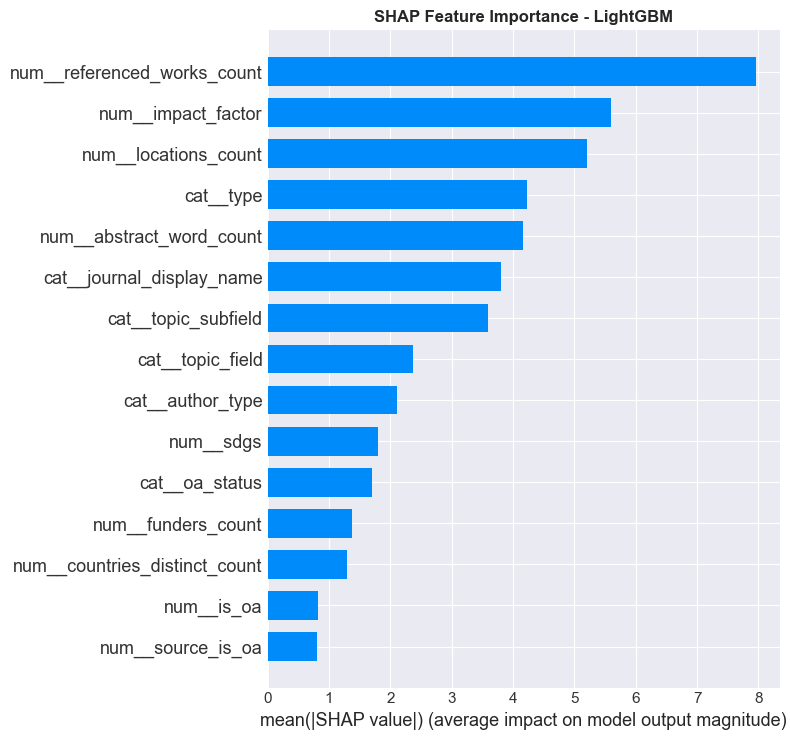

✓ SHAP Bar plot complete


In [119]:
print("=" * 70)
print(f"SHAP ANALYSIS: {best_model_row['Model']} ({best_model_row['Strategy']})")
print("=" * 70)

# Prefer the tuned pipeline when the handoff cell has been executed.
if 'use_tuned_pipeline' in globals() and use_tuned_pipeline and 'best_tuned_model' in globals():
    tuned_preprocessor = best_tuned_model.named_steps['preprocess']
    best_model = best_tuned_model.named_steps['model']
    X_test_shap = tuned_preprocessor.transform(X_test_pipe)
    y_test_shap = y_test_pipe.to_numpy()
    shap_feature_names = list(tuned_preprocessor.get_feature_names_out())
    shap_source_note = f"Using tuned pipeline features from {best_tuned_model_name}"
else:
    # Prepare SHAP data based on best model strategy from the untuned comparison.
    if best_strategy == 'Random 80/20':
        X_test_shap = X_test_s1
        y_test_shap = y_test_s1
    elif best_strategy == 'Time-Based':
        X_test_shap = X_test_s2
        y_test_shap = y_test_s2
    else:  # Stratified
        X_test_shap = X_test_s3
        y_test_shap = y_test_s3
    shap_feature_names = feature_names
    shap_source_note = f"Using untuned comparison split: {best_strategy}"

print(shap_source_note)

# Initialize SHAP explainer (TreeExplainer for tree-based models)
if isinstance(best_model, xgb.XGBRegressor):
    explainer = shap.TreeExplainer(best_model)
elif isinstance(best_model, lgb.LGBMRegressor):
    explainer = shap.TreeExplainer(best_model)
elif isinstance(best_model, CatBoostRegressor):
    explainer = shap.TreeExplainer(best_model)
else:
    # For other models, use KernelExplainer
    explainer = shap.KernelExplainer(best_model.predict, shap.sample(X_test_shap, 50))

# Compute SHAP values
print("Computing SHAP values...")
shap_values = explainer.shap_values(X_test_shap)

# Convert to numpy array if it's a list (common for CatBoost)
if isinstance(shap_values, list):
    shap_values = np.array(shap_values)
shap_values = np.asarray(shap_values, dtype=np.float64)
print("✓ SHAP values computed")

# Summary plot: Bar chart of average |SHAP| per feature
print("\nGenerating SHAP summary plot (bar)...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_shap, feature_names=shap_feature_names, plot_type='bar', show=False)
plt.title(f"SHAP Feature Importance - {best_model_row['Model']}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP Bar plot complete")


Generating feature vs target correlation plots for top 5 SHAP features...


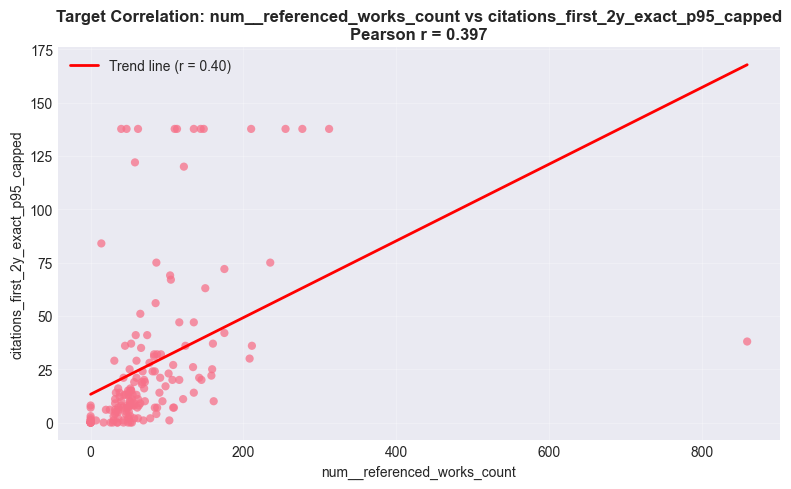

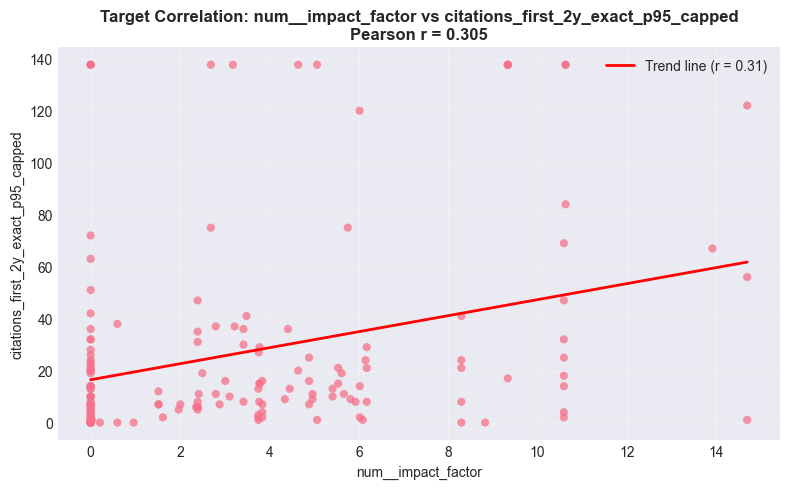

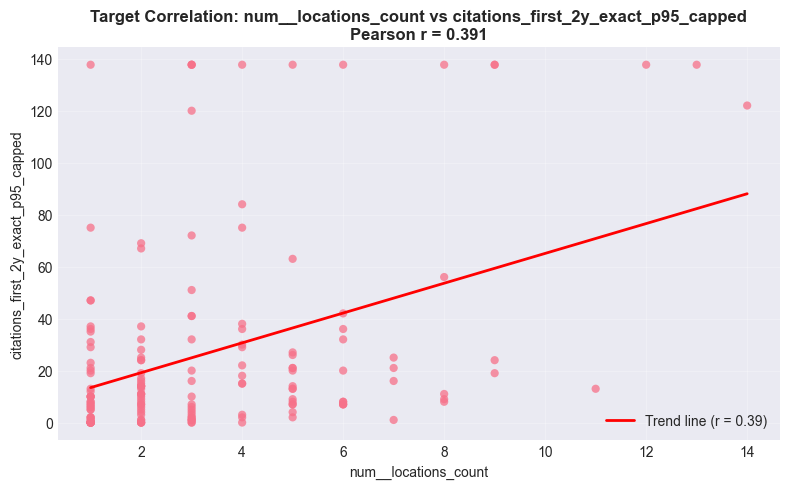

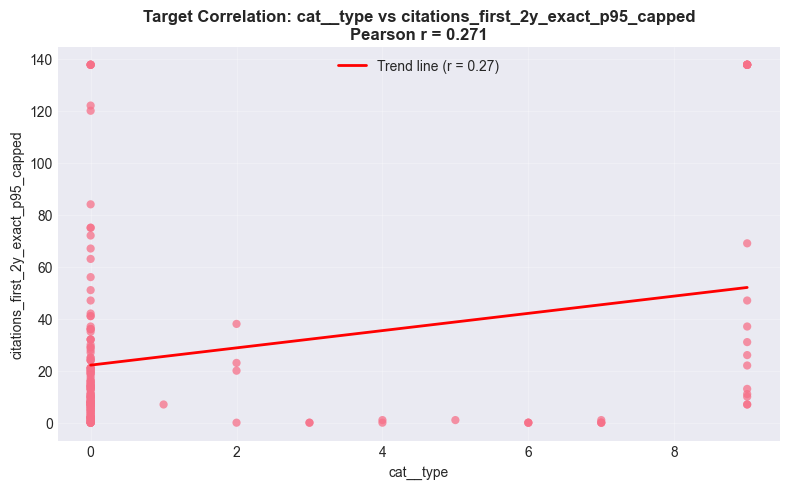

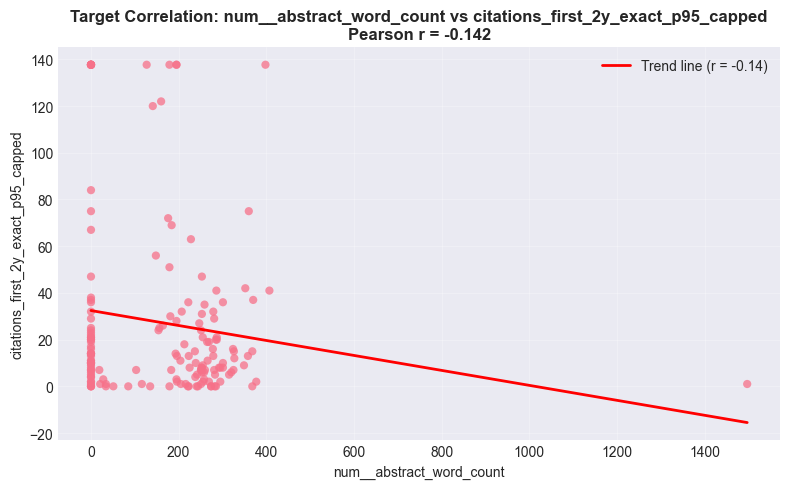

✓ Feature-vs-target correlation plots complete for top 5 SHAP features: ['num__referenced_works_count', 'num__impact_factor', 'num__locations_count', 'cat__type', 'num__abstract_word_count']


In [135]:
# Correlation plots for top 5 SHAP features (Y-axis = target variable)
print("\nGenerating feature vs target correlation plots for top 5 SHAP features...")

# Keep feature names aligned with the SHAP matrix source (tuned or untuned flow).
active_feature_names = shap_feature_names if 'shap_feature_names' in globals() else feature_names

# Identify top 5 features by mean absolute SHAP value
mean_shap_vals = np.abs(shap_values).mean(axis=0)
top_5_indices = np.argsort(mean_shap_vals)[-5:][::-1]
top_5_features = [active_feature_names[i] for i in top_5_indices]

# Numeric arrays for robust plotting
X_test_shap_numeric = np.asarray(X_test_shap, dtype=np.float64)
y_target = np.asarray(y_test_shap, dtype=np.float64)

for feature_idx in top_5_indices:
    x_feature = X_test_shap_numeric[:, feature_idx]

    # Keep only finite values
    valid_mask = np.isfinite(x_feature) & np.isfinite(y_target)
    x_clean = x_feature[valid_mask]
    y_clean = y_target[valid_mask]

    if len(x_clean) < 2:
        print(f"Skipping {active_feature_names[feature_idx]} (not enough valid points).")
        continue

    # Pearson correlation
    corr = np.corrcoef(x_clean, y_clean)[0, 1]

    plt.figure(figsize=(8, 5))
    plt.scatter(x_clean, y_clean, alpha=0.75, s=35, edgecolors='none')

    # Add regression/trend line when feature has variation
    if np.std(x_clean) > 0:
        slope, intercept = np.polyfit(x_clean, y_clean, 1)
        x_line = np.linspace(x_clean.min(), x_clean.max(), 200)
        y_line = slope * x_line + intercept
        plt.plot(x_line, y_line, color='red', linewidth=2, label=f"Trend line (r = {corr:.2f})")
        plt.legend(loc='best')

    plt.xlabel(active_feature_names[feature_idx])
    plt.ylabel(TARGET)
    plt.title(
        f"Target Correlation: {active_feature_names[feature_idx]} vs {TARGET}\n"
        f"Pearson r = {corr:.3f}",
        fontsize=12,
        fontweight='bold'
    )
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

print(f"✓ Feature-vs-target correlation plots complete for top 5 SHAP features: {top_5_features}")


Generating SHAP summary plot (violin)...


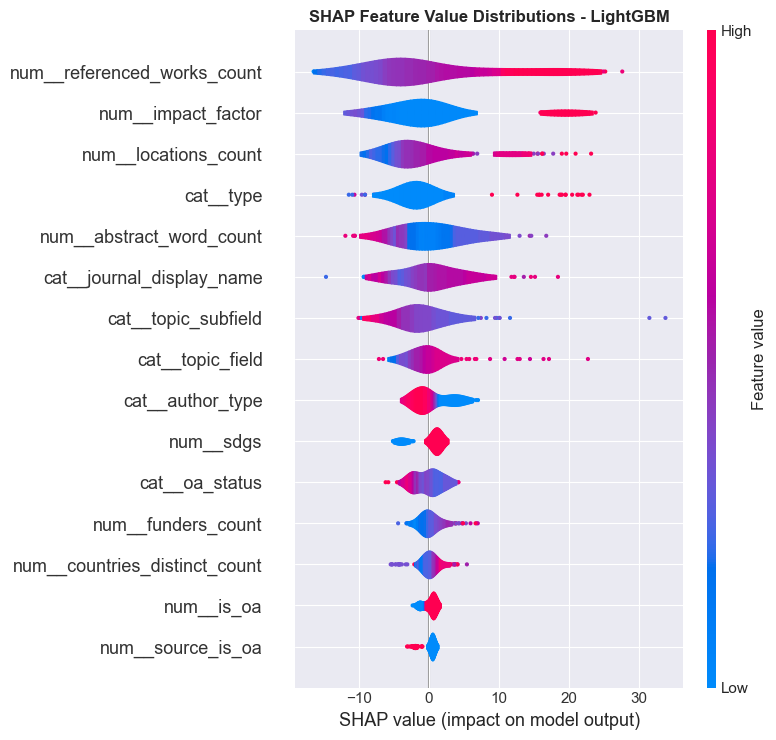

✓ SHAP Violin plot complete

Generating SHAP waterfall plot for single prediction...


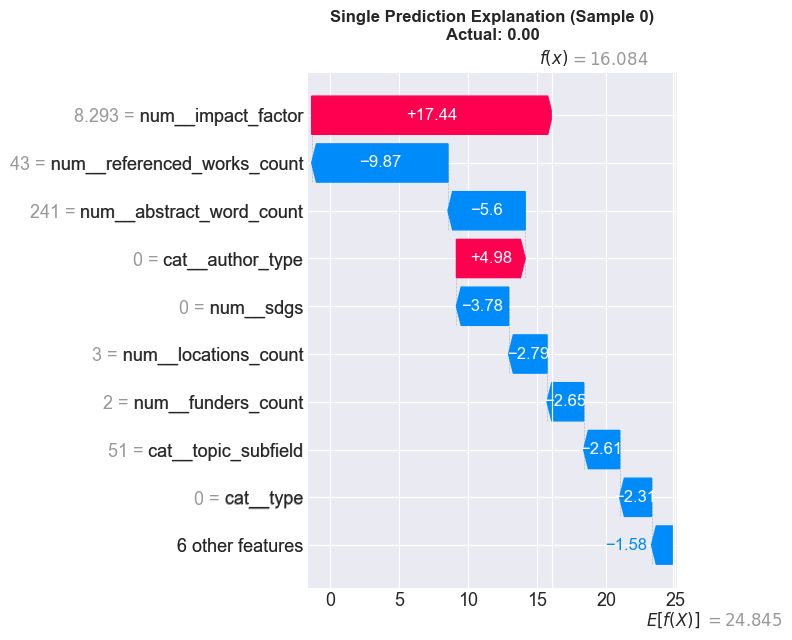

✓ SHAP Waterfall plot complete


In [136]:
# Summary plot: Violin chart of SHAP value distributions
print("\nGenerating SHAP summary plot (violin)...")
plt.figure(figsize=(10, 8))

active_feature_names = shap_feature_names if 'shap_feature_names' in globals() else feature_names

# For violin plot, we need numeric X_test_shap - convert if necessary
X_test_shap_numeric = np.asarray(X_test_shap, dtype=np.float64)

try:
    shap.summary_plot(shap_values, X_test_shap_numeric, feature_names=active_feature_names, plot_type='violin', show=False)
except TypeError:
    # If violin plot fails due to data type issues, use force plot as fallback
    print("Violin plot encountered data type issues. Using force plot instead...")
    plt.clf()
    fig = plt.figure(figsize=(10, 8))
    shap.force_plot(explainer.expected_value, shap_values[:50], X_test_shap_numeric[:50], 
                    feature_names=active_feature_names, matplotlib=True, show=False)

plt.title(f"SHAP Feature Value Distributions - {best_model_row['Model']}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP Violin plot complete")

# Single prediction: Waterfall plot for first test sample
print("\nGenerating SHAP waterfall plot for single prediction...")
sample_idx = 0
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap.Explanation(values=shap_values[sample_idx], 
                                      base_values=explainer.expected_value,
                                      data=X_test_shap_numeric[sample_idx],
                                      feature_names=active_feature_names), show=False)
plt.title(f"Single Prediction Explanation (Sample {sample_idx})\nActual: {y_test_shap[sample_idx]:.2f}", 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP Waterfall plot complete")

## Section 9: Random Forest Validation

Train a Random Forest as a parallel model to cross-check feature importance rankings against gradient boosted models.

In [122]:
print("=" * 70)
print("RANDOM FOREST VALIDATION MODEL")
print("=" * 70)
print("Training Random Forest on Strategy 1 (Random 80/20) split for comparison...")

# Train Random Forest on same split as best model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_s1, y_train_s1)

# Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test_s1)
mae_rf = mean_absolute_error(y_test_s1, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_s1, y_pred_rf))
r2_rf = r2_score(y_test_s1, y_pred_rf)

print(f"\nRandom Forest Performance:")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")

# Extract feature importance from Random Forest
rf_importance = rf_model.feature_importances_
rf_importance_normalized = rf_importance / rf_importance.sum()

print(f"\nTop 10 features by Random Forest importance:")
rf_top_indices = np.argsort(rf_importance)[-10:][::-1]
for rank, idx in enumerate(rf_top_indices, 1):
    print(f"  {rank:2d}. {feature_names[idx]:30s} = {rf_importance_normalized[idx]:.4f}")

print("\n✓ Random Forest validation complete")

RANDOM FOREST VALIDATION MODEL
Training Random Forest on Strategy 1 (Random 80/20) split for comparison...

Random Forest Performance:
  MAE:  16.6136
  RMSE: 26.9656
  R²:   0.4915

Top 10 features by Random Forest importance:
   1. referenced_works_count         = 0.2731
   2. impact_factor                  = 0.1982
   3. journal_display_name           = 0.1735
   4. countries_distinct_count       = 0.0952
   5. type                           = 0.0687
   6. locations_count                = 0.0646
   7. abstract_word_count            = 0.0460
   8. funders_count                  = 0.0202
   9. topic_field                    = 0.0177
  10. topic_subfield                 = 0.0170

✓ Random Forest validation complete


## Section 10: Feature Importance Comparison Across All Models

In [128]:
print("=" * 70)
print("FEATURE IMPORTANCE COMPARISON")
print("=" * 70)

from sklearn.inspection import permutation_importance

# Keep feature names aligned with the active SHAP matrix.
active_feature_names = shap_feature_names if 'shap_feature_names' in globals() else feature_names

if 'use_tuned_pipeline' in globals() and use_tuned_pipeline and 'best_tuned_model' in globals():
    print("Mode: tuned pipeline comparison (same feature space for fair interpretation).")

    perm_result = permutation_importance(
        best_tuned_model,
        X_test_pipe,
        y_test_pipe,
        n_repeats=8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    perm_importance = perm_result.importances_mean
    perm_importance_norm = perm_importance / (perm_importance.sum() + 1e-12)

    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_importance_norm = shap_importance / (shap_importance.sum() + 1e-12)

    # Defensive alignment in case lengths differ after preprocessing updates
    n_common = min(len(active_feature_names), len(perm_importance_norm), len(shap_importance_norm))
    importance_comparison = pd.DataFrame({
        'Feature': active_feature_names[:n_common],
        'Permutation': perm_importance_norm[:n_common],
        'SHAP': shap_importance_norm[:n_common],
    })

    for col in ['Permutation', 'SHAP']:
        importance_comparison[f'{col}_Rank'] = importance_comparison[col].rank(ascending=False)
    importance_comparison['Avg_Rank'] = importance_comparison[['Permutation_Rank', 'SHAP_Rank']].mean(axis=1)

    importance_comparison_sorted = importance_comparison.sort_values('Avg_Rank')

    print("\nTOP 15 FEATURES (Permutation + SHAP, tuned model):")
    print(importance_comparison_sorted[['Feature', 'Permutation', 'SHAP', 'Avg_Rank']].head(15).to_string(index=False))

    print("\nBOTTOM 10 FEATURES (low joint importance):")
    print(importance_comparison_sorted[['Feature', 'Permutation', 'SHAP', 'Avg_Rank']].tail(10).to_string(index=False))

else:
    print("Mode: untuned model-family comparison (XGBoost/LightGBM/CatBoost/RandomForest + SHAP).")

    # Extract feature importances from untuned family models
    xgb_importance = xgb_s1.feature_importances_
    lgb_importance = lgb_s1.feature_importances_
    cb_importance = cb_s1.feature_importances_
    rf_importance_norm_copy = rf_importance_normalized.copy()

    # Normalize importances
    xgb_importance_norm = xgb_importance / (xgb_importance.sum() + 1e-12)
    lgb_importance_norm = lgb_importance / (lgb_importance.sum() + 1e-12)
    cb_importance_norm = cb_importance / (cb_importance.sum() + 1e-12)
    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_importance_norm = shap_importance / (shap_importance.sum() + 1e-12)

    n_common = min(
        len(feature_names),
        len(xgb_importance_norm),
        len(lgb_importance_norm),
        len(cb_importance_norm),
        len(rf_importance_norm_copy),
        len(shap_importance_norm),
    )

    importance_comparison = pd.DataFrame({
        'Feature': feature_names[:n_common],
        'XGBoost': xgb_importance_norm[:n_common],
        'LightGBM': lgb_importance_norm[:n_common],
        'CatBoost': cb_importance_norm[:n_common],
        'RandomForest': rf_importance_norm_copy[:n_common],
        'SHAP': shap_importance_norm[:n_common],
    })

    for col in ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP']:
        importance_comparison[f'{col}_Rank'] = importance_comparison[col].rank(ascending=False)

    importance_comparison['Avg_Rank'] = importance_comparison[[
        'XGBoost_Rank', 'LightGBM_Rank', 'CatBoost_Rank', 'RandomForest_Rank', 'SHAP_Rank'
    ]].mean(axis=1)

    importance_comparison_sorted = importance_comparison.sort_values('Avg_Rank')

    print("\nTOP 15 FEATURES (sorted by average rank across all models):")
    print(importance_comparison_sorted[['Feature', 'XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP', 'Avg_Rank']].head(15).to_string(index=False))

    print("\nBOTTOM 10 FEATURES (likely noise or weak signals):")
    print(importance_comparison_sorted[['Feature', 'XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP', 'Avg_Rank']].tail(10).to_string(index=False))

FEATURE IMPORTANCE COMPARISON
Mode: tuned pipeline comparison (same feature space for fair interpretation).

TOP 15 FEATURES (Permutation + SHAP, tuned model):
                      Feature  Permutation     SHAP  Avg_Rank
           num__impact_factor     0.340960 0.119503       1.5
     num__abstract_word_count     0.133006 0.088870       4.0
         num__locations_count     0.040134 0.111087       5.0
  num__referenced_works_count     0.020130 0.169984       6.0
                    cat__type     0.036116 0.090354       6.0
num__countries_distinct_count     0.161022 0.027701       7.5
               cat__oa_status     0.067076 0.036242       8.0
             cat__topic_field     0.022160 0.050787       9.0
            num__source_is_oa     0.097912 0.017269       9.5
                    num__sdgs     0.023955 0.038404       9.5
          cat__topic_subfield     0.007379 0.076640      10.0
                   num__is_oa     0.041489 0.017545      10.0
    cat__journal_display_name    -

In [129]:
# Ranking correlation analysis (Spearman correlation)
from scipy.stats import spearmanr

print("\n" + "=" * 70)
print("RANKING CORRELATION (Spearman) ACROSS IMPORTANCE SOURCES")
print("=" * 70)

if {'Permutation_Rank', 'SHAP_Rank'}.issubset(set(importance_comparison.columns)):
    corr, pvalue = spearmanr(importance_comparison['Permutation_Rank'], importance_comparison['SHAP_Rank'])
    corr_df = pd.DataFrame([[1.0, corr], [corr, 1.0]], 
                           index=['Permutation', 'SHAP'], 
                           columns=['Permutation', 'SHAP'])
    print(corr_df.round(3).to_string())
    print(f"\nSpearman rho (Permutation vs SHAP): {corr:.3f} | p-value: {pvalue:.3e}")
else:
    rank_cols = ['XGBoost_Rank', 'LightGBM_Rank', 'CatBoost_Rank', 'RandomForest_Rank', 'SHAP_Rank']
    model_names_for_corr = ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP']

    # Compute Spearman correlations
    correlation_matrix = np.zeros((5, 5))
    for i, model1 in enumerate(rank_cols):
        for j, model2 in enumerate(rank_cols):
            corr, _ = spearmanr(importance_comparison[model1], importance_comparison[model2])
            correlation_matrix[i, j] = corr

    corr_df = pd.DataFrame(correlation_matrix, 
                           index=model_names_for_corr, 
                           columns=model_names_for_corr)
    print(corr_df.round(3).to_string())

print("\nInterpretation:")
print("  • Values close to 1.0 = strong agreement between importance rankings")
print("  • Values close to 0   = disagreement (potential instability or model-specific patterns)")
print("  • High correlations confirm that importance signals are robust")


RANKING CORRELATION (Spearman) ACROSS IMPORTANCE SOURCES
             Permutation   SHAP
Permutation        1.000 -0.118
SHAP              -0.118  1.000

Spearman rho (Permutation vs SHAP): -0.118 | p-value: 6.757e-01

Interpretation:
  • Values close to 1.0 = strong agreement between importance rankings
  • Values close to 0   = disagreement (potential instability or model-specific patterns)
  • High correlations confirm that importance signals are robust



Visualizing feature importance alignment...


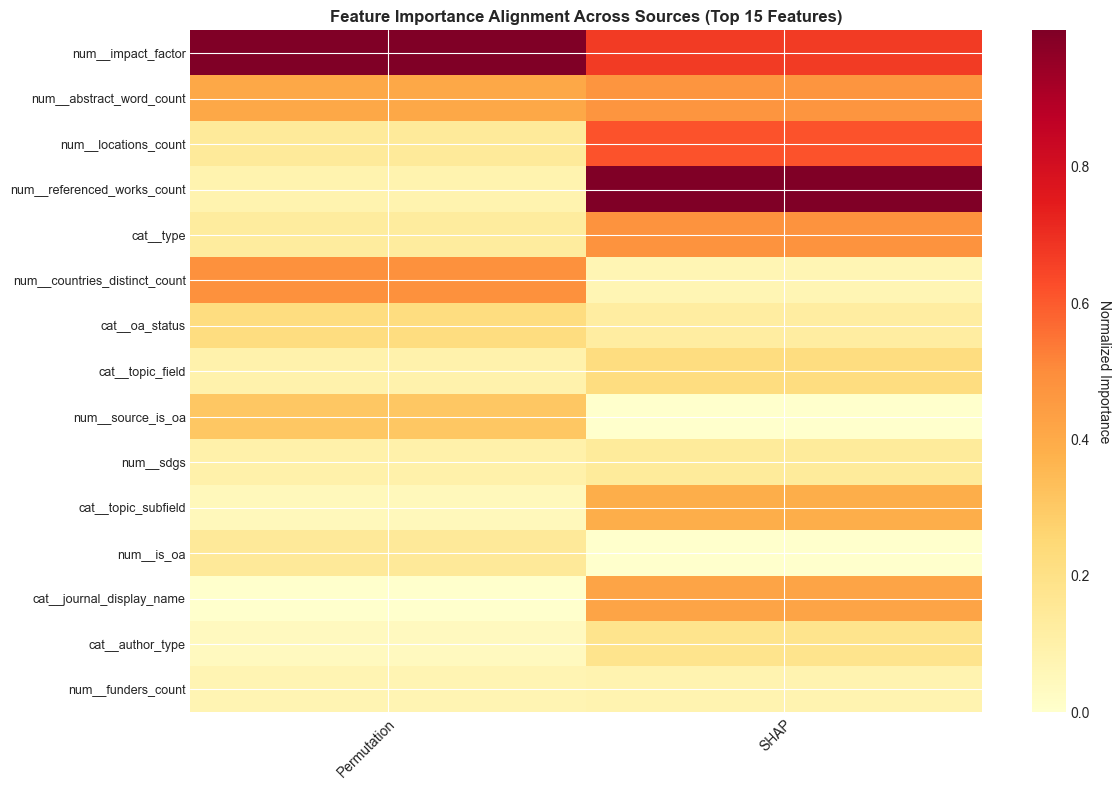

✓ Feature importance comparison complete


In [130]:
# Visualization: Feature importance heatmap for top features
print("\nVisualizing feature importance alignment...")

importance_cols = [c for c in ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'Permutation', 'SHAP'] if c in importance_comparison.columns]
top_n = 20 if len(importance_comparison) >= 20 else len(importance_comparison)
top_features_plot = importance_comparison_sorted.head(top_n).copy()

fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap data
heatmap_data = top_features_plot[importance_cols].values

# Normalize by column (each source scaled to 0-1)
heatmap_data_normalized = (heatmap_data - heatmap_data.min(axis=0)) / (heatmap_data.max(axis=0) - heatmap_data.min(axis=0) + 1e-8)

im = ax.imshow(heatmap_data_normalized, cmap='YlOrRd', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(len(importance_cols)))
ax.set_yticks(np.arange(len(top_features_plot)))
ax.set_xticklabels(importance_cols)
ax.set_yticklabels(top_features_plot['Feature'].values, fontsize=9)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Importance', rotation=270, labelpad=15)

ax.set_title(f'Feature Importance Alignment Across Sources (Top {top_n} Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Feature importance comparison complete")

## Section 11: Train-Test Strategy Comparison & Analysis

In [126]:
print("=" * 100)
print("TRAIN-TEST STRATEGY COMPARISON")
print("=" * 100)

# Focus on best main models: XGBoost, LightGBM, CatBoost across all 3 strategies
strategy_comparison = results_summary[results_summary['Model'].isin(['XGBoost', 'LightGBM', 'CatBoost'])].copy()

print("\nPerformance by Strategy:")
print(strategy_comparison.to_string(index=False))

# Pivot for easier comparison
strategy_pivot_r2 = strategy_comparison.pivot(index='Model', columns='Strategy', values='R²')
strategy_pivot_mae = strategy_comparison.pivot(index='Model', columns='Strategy', values='MAE')
strategy_pivot_rmse = strategy_comparison.pivot(index='Model', columns='Strategy', values='RMSE')

print("\n" + "=" * 70)
print("R² SCORE BY STRATEGY:")
print("=" * 70)
print(strategy_pivot_r2.round(4).to_string())

print("\n" + "=" * 70)
print("STRATEGY ANALYSIS & RECOMMENDATIONS:")
print("=" * 70)

print("\n1. RANDOM 80/20 SPLIT")
print("   ✓ Pros: Standard practice; balanced sampling; reproducible")
print("   ✗ Cons: May leak temporal patterns (mixing past & future citations)")
print(f"   → Best for: Baseline comparison; understanding overall model capability")
print(f"   → Avg R² across main models: {strategy_pivot_r2['Random 80/20'].mean():.4f}")

print("\n2. TIME-BASED SPLIT (Earlier years → train, Recent years → test)")
print("   ✓ Pros: Realistic scenario; tests forward prediction; avoids data leakage")
print("   ✗ Cons: May imbalance class distributions; fewer recent citations")
print(f"   → Best for: Validating forward prediction; detecting temporal drift")
print(f"   → Avg R² across main models: {strategy_pivot_r2['Time-Based'].mean():.4f}")

print("\n3. STRATIFIED SPLIT (By publication topic)")
print("   ✓ Pros: Ensures balanced representation of key groups; robust across topics")
print("   ✗ Cons: No temporal validation; may overfit to group patterns")
print(f"   → Best for: Confirming features generalize across publication domains")
print(f"   → Avg R² across main models: {strategy_pivot_r2['Stratified'].mean():.4f}")

# Performance variance across strategies
print("\n" + "=" * 70)
print("MODEL PERFORMANCE STABILITY ACROSS STRATEGIES:")
print("=" * 70)

stability = pd.DataFrame({
    'Model': strategy_pivot_r2.index,
    'R² Range': strategy_pivot_r2.max(axis=1) - strategy_pivot_r2.min(axis=1),
    'R² Std Dev': strategy_pivot_r2.std(axis=1),
    'R² CoeffVar': (strategy_pivot_r2.std(axis=1) / strategy_pivot_r2.mean(axis=1)).round(3)
})

print(stability.to_string(index=False))
print("\nInterpretation:")
print("  • Low CoeffVar = stable performance across strategies (robust model)")
print("  • High CoeffVar = sensitive to train-test split choice (may overfit to specific data distribution)")

TRAIN-TEST STRATEGY COMPARISON

Performance by Strategy:
   Model     Strategy       MAE      RMSE        R²
 XGBoost Random 80/20 15.361859 25.746283  0.536417
 XGBoost   Time-Based 13.868215 21.982299 -0.893964
 XGBoost   Stratified 15.092539 23.578956  0.583541
LightGBM Random 80/20 17.092801 27.164050  0.483955
LightGBM   Time-Based 13.846774 19.736225 -0.526700
LightGBM   Stratified 16.399793 23.593947  0.583011
CatBoost Random 80/20 16.297557 25.957220  0.528790
CatBoost   Time-Based 14.137097 20.633995 -0.668753
CatBoost   Stratified 15.667687 24.734582  0.541718

R² SCORE BY STRATEGY:
Strategy  Random 80/20  Stratified  Time-Based
Model                                         
CatBoost        0.5288      0.5417     -0.6688
LightGBM        0.4840      0.5830     -0.5267
XGBoost         0.5364      0.5835     -0.8940

STRATEGY ANALYSIS & RECOMMENDATIONS:

1. RANDOM 80/20 SPLIT
   ✓ Pros: Standard practice; balanced sampling; reproducible
   ✗ Cons: May leak temporal patterns (mix

## Section 11.5: Overfitting vs Underfitting Diagnostics (Best Model)

This section adds regression-appropriate diagnostics for the active best model.

- AUC/ROC is not used because the target is continuous (regression), not a classification label.
- We focus on train-test generalization gap, cross-validation stability, learning curves, and residual behavior.

OVERFITTING / UNDERFITTING DIAGNOSTICS
Active best model: LightGBM
Evaluation split: Random 80/20 (pipeline tuned)

Split       MAE     MedAE      RMSE    RMSLE       R²
Train  8.728708  5.582014 12.636646 0.814925 0.870548
 Test 18.124221 10.785280 26.951605 1.312057 0.491996

Generalization diagnosis:
- R² gap (train - test): 0.3786
- RMSE ratio (test/train): 2.1328
- Status: Likely overfitting (high variance): strong train-test performance gap.

5-Fold CV summary (train split only):
Metric   CV Mean   CV Std
   MAE 18.199049 1.170873
  RMSE 26.694173 1.784704
    R²  0.408944 0.097996


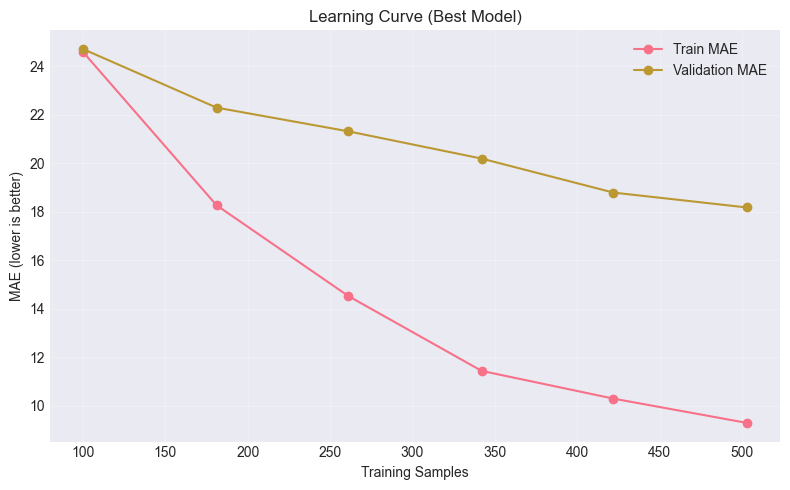

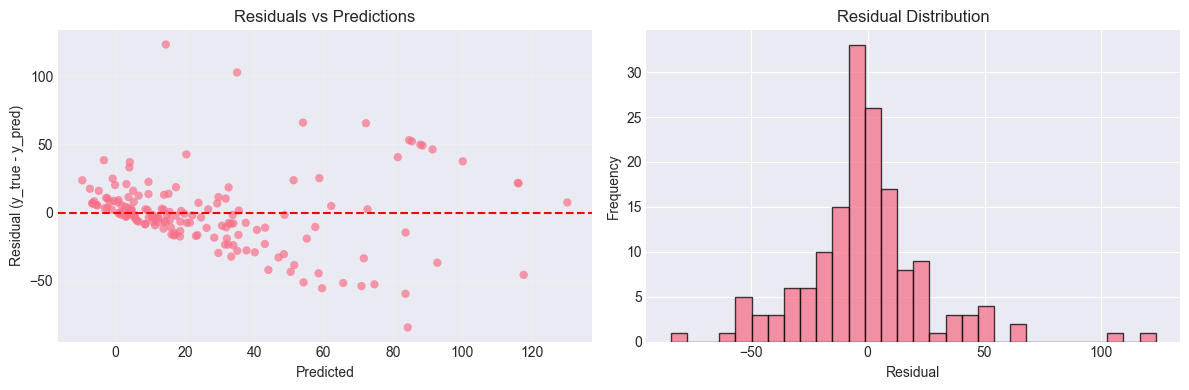


✓ Overfitting/underfitting diagnostics completed


In [133]:
from sklearn.base import clone
from sklearn.model_selection import KFold, cross_validate, learning_curve
from sklearn.metrics import median_absolute_error

print("=" * 100)
print("OVERFITTING / UNDERFITTING DIAGNOSTICS")
print("=" * 100)

def _safe_rmsle(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), 0.0)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0.0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

# Resolve active model/data path
if 'use_tuned_pipeline' in globals() and use_tuned_pipeline and 'best_tuned_model' in globals():
    active_model = best_tuned_model
    X_train_diag, X_test_diag = X_train_pipe, X_test_pipe
    y_train_diag, y_test_diag = y_train_pipe, y_test_pipe
    active_model_name = best_tuned_model_name
    active_split_name = 'Random 80/20 (pipeline tuned)'
else:
    active_model = best_model
    if best_strategy == 'Random 80/20':
        X_train_diag, X_test_diag = X_train_s1, X_test_s1
        y_train_diag, y_test_diag = y_train_s1, y_test_s1
    elif best_strategy == 'Time-Based':
        X_train_diag, X_test_diag = X_train_s2, X_test_s2
        y_train_diag, y_test_diag = y_train_s2, y_test_s2
    else:
        X_train_diag, X_test_diag = X_train_s3, X_test_s3
        y_train_diag, y_test_diag = y_train_s3, y_test_s3
    active_model_name = str(best_model_row['Model'])
    active_split_name = best_strategy

# Train predictions vs test predictions
train_pred = active_model.predict(X_train_diag)
test_pred = active_model.predict(X_test_diag)

metrics_diag = pd.DataFrame([
    {
        'Split': 'Train',
        'MAE': mean_absolute_error(y_train_diag, train_pred),
        'MedAE': median_absolute_error(y_train_diag, train_pred),
        'RMSE': np.sqrt(mean_squared_error(y_train_diag, train_pred)),
        'RMSLE': _safe_rmsle(y_train_diag, train_pred),
        'R²': r2_score(y_train_diag, train_pred),
    },
    {
        'Split': 'Test',
        'MAE': mean_absolute_error(y_test_diag, test_pred),
        'MedAE': median_absolute_error(y_test_diag, test_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_diag, test_pred)),
        'RMSLE': _safe_rmsle(y_test_diag, test_pred),
        'R²': r2_score(y_test_diag, test_pred),
    },
])

print(f"Active best model: {active_model_name}")
print(f"Evaluation split: {active_split_name}\n")
print(metrics_diag.to_string(index=False))

# Generalization-gap heuristics
gap_r2 = float(metrics_diag.loc[metrics_diag['Split'] == 'Train', 'R²'].iloc[0] - metrics_diag.loc[metrics_diag['Split'] == 'Test', 'R²'].iloc[0])
gap_rmse_ratio = float(metrics_diag.loc[metrics_diag['Split'] == 'Test', 'RMSE'].iloc[0] / (metrics_diag.loc[metrics_diag['Split'] == 'Train', 'RMSE'].iloc[0] + 1e-12))

if (metrics_diag.loc[1, 'R²'] < 0.20) and (metrics_diag.loc[0, 'R²'] < 0.30):
    fit_status = 'Likely underfitting (high bias): low explanatory power in both train and test.'
elif (gap_r2 > 0.15) or (gap_rmse_ratio > 1.30):
    fit_status = 'Likely overfitting (high variance): strong train-test performance gap.'
else:
    fit_status = 'Reasonable bias-variance balance for current feature set and split.'

print("\nGeneralization diagnosis:")
print(f"- R² gap (train - test): {gap_r2:.4f}")
print(f"- RMSE ratio (test/train): {gap_rmse_ratio:.4f}")
print(f"- Status: {fit_status}")

# Cross-validation on train split for stability
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2',
}

cv_model = clone(active_model)
cv_results = cross_validate(
    cv_model,
    X_train_diag,
    y_train_diag,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
    error_score='raise',
)

cv_summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'CV Mean': [
        -cv_results['test_mae'].mean(),
        -cv_results['test_rmse'].mean(),
        cv_results['test_r2'].mean(),
    ],
    'CV Std': [
        cv_results['test_mae'].std(),
        cv_results['test_rmse'].std(),
        cv_results['test_r2'].std(),
    ],
})

print("\n5-Fold CV summary (train split only):")
print(cv_summary.to_string(index=False))

# Learning curve (MAE)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=clone(active_model),
    X=X_train_diag,
    y=y_train_diag,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE,
    error_score='raise',
)

train_mae_curve = -train_scores.mean(axis=1)
val_mae_curve = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mae_curve, marker='o', label='Train MAE')
plt.plot(train_sizes, val_mae_curve, marker='o', label='Validation MAE')
plt.xlabel('Training Samples')
plt.ylabel('MAE (lower is better)')
plt.title('Learning Curve (Best Model)')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Residual diagnostics
residuals_test = np.asarray(y_test_diag) - np.asarray(test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(test_pred, residuals_test, alpha=0.7, edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual (y_true - y_pred)')
axes[0].set_title('Residuals vs Predictions')
axes[0].grid(alpha=0.2)

axes[1].hist(residuals_test, bins=30, edgecolor='black', alpha=0.75)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

# Store diagnostics for final summary cell
diagnostics_summary = {
    'active_model_name': active_model_name,
    'active_split_name': active_split_name,
    'r2_gap': gap_r2,
    'rmse_ratio_test_train': gap_rmse_ratio,
    'fit_status': fit_status,
    'test_mae': float(metrics_diag.loc[metrics_diag['Split'] == 'Test', 'MAE'].iloc[0]),
    'test_rmse': float(metrics_diag.loc[metrics_diag['Split'] == 'Test', 'RMSE'].iloc[0]),
    'test_r2': float(metrics_diag.loc[metrics_diag['Split'] == 'Test', 'R²'].iloc[0]),
    'cv_r2_mean': float(cv_summary.loc[cv_summary['Metric'] == 'R²', 'CV Mean'].iloc[0]),
    'cv_r2_std': float(cv_summary.loc[cv_summary['Metric'] == 'R²', 'CV Std'].iloc[0]),
}

print("\n✓ Overfitting/underfitting diagnostics completed")

## Section 12: Final Summary & Recommendations

In [137]:
print("=" * 100)
print("FINAL SUMMARY & RECOMMENDATIONS")
print("=" * 100)

print("\nBEST PERFORMING MODEL")
print("-" * 70)
print(f"Model: {best_model_row['Model']}")
print(f"Strategy: {best_model_row['Strategy']}")
print(f"R² Score: {best_model_row['R²']:.4f}")
print(f"MAE: {best_model_row['MAE']:.4f}")
print(f"RMSE: {best_model_row['RMSE']:.4f}")

if 'diagnostics_summary' in globals():
    print("\nGENERALIZATION DIAGNOSTIC (Overfitting / Underfitting)")
    print("-" * 70)
    print(f"Active model analyzed: {diagnostics_summary['active_model_name']}")
    print(f"Evaluation split: {diagnostics_summary['active_split_name']}")
    print(f"Test R²: {diagnostics_summary['test_r2']:.4f}")
    print(f"Test MAE: {diagnostics_summary['test_mae']:.4f}")
    print(f"Test RMSE: {diagnostics_summary['test_rmse']:.4f}")
    print(f"CV R² mean ± std: {diagnostics_summary['cv_r2_mean']:.4f} ± {diagnostics_summary['cv_r2_std']:.4f}")
    print(f"R² gap (train - test): {diagnostics_summary['r2_gap']:.4f}")
    print(f"RMSE ratio (test/train): {diagnostics_summary['rmse_ratio_test_train']:.4f}")
    print(f"Diagnosis: {diagnostics_summary['fit_status']}")

print("\nTOP 10 MOST IMPORTANT FEATURES")
print("-" * 70)

importance_metric_cols = [c for c in ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'Permutation', 'SHAP'] if c in importance_comparison_sorted.columns]

top10 = importance_comparison_sorted.head(10).copy()
for rank, (_, row) in enumerate(top10.iterrows(), 1):
    avg_importance = row[importance_metric_cols].mean() if len(importance_metric_cols) > 0 else np.nan
    print(f"{rank:2d}. {row['Feature'][:50]:50s} -> Avg Importance: {avg_importance:.4f}")

print("\nFEATURES WITH LOW/INCONSISTENT IMPORTANCE")
print("-" * 70)

rank_cols_dynamic = [c for c in importance_comparison.columns if c.endswith('_Rank')]
if rank_cols_dynamic:
    importance_comparison['Rank_StdDev'] = importance_comparison[rank_cols_dynamic].std(axis=1)
    unstable_features = importance_comparison[
        importance_comparison['Rank_StdDev'] > importance_comparison['Rank_StdDev'].quantile(0.75)
    ].copy()
    print(f"Found {len(unstable_features)} features with inconsistent importance across sources:")
    cols_to_show = [c for c in ['Feature', 'Avg_Rank', 'Rank_StdDev'] if c in unstable_features.columns]
    print(unstable_features[cols_to_show].head(5).to_string(index=False))
else:
    print("Insufficient ranking columns to compute consistency spread.")

print("\nRECOMMENDATIONS")
print("-" * 70)
print(f"1. Production candidate: {best_model_row['Model']} with {best_model_row['Strategy']} strategy")
print("2. Keep the overfitting/underfitting diagnostics section as mandatory before each model refresh.")
print("3. Prefer reporting MAE, RMSE, R² and RMSLE for this regression target (AUC/ROC is not applicable).")
print("4. Track temporal stability: rerun time-based evaluation when new publication cohorts are added.")
print("5. If overfitting signs increase, reduce model complexity or strengthen regularization before adding features.")

print("\n" + "=" * 100)
print("PIPELINE COMPLETE")
print("=" * 100)

FINAL SUMMARY & RECOMMENDATIONS

BEST PERFORMING MODEL
----------------------------------------------------------------------
Model: LightGBM
Strategy: Tuned pipeline (Random 80/20)
R² Score: 0.4920
MAE: 18.1242
RMSE: 26.9516

GENERALIZATION DIAGNOSTIC (Overfitting / Underfitting)
----------------------------------------------------------------------
Active model analyzed: LightGBM
Evaluation split: Random 80/20 (pipeline tuned)
Test R²: 0.4920
Test MAE: 18.1242
Test RMSE: 26.9516
CV R² mean ± std: 0.4089 ± 0.0980
R² gap (train - test): 0.3786
RMSE ratio (test/train): 2.1328
Diagnosis: Likely overfitting (high variance): strong train-test performance gap.

TOP 10 MOST IMPORTANT FEATURES
----------------------------------------------------------------------
 1. num__impact_factor                                 -> Avg Importance: 0.2302
 2. num__abstract_word_count                           -> Avg Importance: 0.1109
 3. num__locations_count                               -> Avg Importanc